# Frequency Distribution

## Imports

In [50]:
from helper import *
from caen_digitizer import *

# data
import uproot
import numpy as np
import awkward as ak
import polars as pl
from tqdm import tqdm

# plotting
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter

In [51]:
plt.rcParams.update({
    "figure.figsize": (6,4),
    "font.size": 10, 
    "legend.fontsize": 13, 
    "legend.labelspacing": 0.2, 
    "figure.dpi": 100, 
    "text.usetex": False,
    "text.latex.preamble": r"\usepackage{sfmath}",
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
})

## Retrieve data

In [52]:
#Set file directory
# fileDir = "/Users/andyyu/Documents/Python/HEP/dawson_hep/scintillating_chamber/data_analysis/data"
fileDir = "H:/bl4s/DATA/dawsons/"

# list of run numbers to load
run_indices = np.concatenate([np.arange(1, 17 + 1), np.arange(19, 35 + 1)])
print(run_indices)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35]


In [53]:
#Read every data and put it into a list
dfs = []
for i in tqdm(run_indices):
    data = digitizer(f'{fileDir}/run{i:06}.root', events=None, channels=[i for i in range(17, 27) ], signal_filter='converted')
    dfs.append(data)

100%|██████████| 34/34 [02:56<00:00,  5.20s/it]


In [54]:
# Interleaving
dfs_interleaved = []
set_a, set_b = dfs[:17], dfs[17:]
print(f"{len(dfs)} {len(set_a)} {len(set_b)}")

for (a, b) in zip(set_a, set_b):
    dfs_interleaved.append(a)
    dfs_interleaved.append(b)

dfs_interleaved

34 17 17


## Masking Function

In [55]:
def getMaxMask(data, getMask, n):
    #Create a mask
    ch_event = getMask(0, data, n)

    #Loop through all the channels and see which has the most hits after masking
    for _channel_trigger in range(1,10):

        masked = getMask(_channel_trigger, data, n)


        if masked[0].shape[0] > ch_event[0].shape[0]:
            ch_event = masked
    

    return ch_event[0]


def getThresholdMask(_channel_trigger, data, threshold):

    #Create the threshold mask
    signal_max = data.waveforms['amplitude'][:, _channel_trigger]
    signal_min = data.waveforms['wave'][:, _channel_trigger].min(axis=1)
    mask_event = (signal_min > -15) & (signal_max > threshold)

    return np.where(mask_event)

def getSNRMask(_channel_trigger, data, SNR_factor):

    #Set the number of samples we want to take to get the mean of the noise
    samples = 50
    sample_head = data.waveforms["wave"][2][_channel_trigger][:samples]

    mean = np.mean(np.abs(sample_head))

    #Calculate signal to noise ratio
    SNR = sample_head.max() / mean

    
    #Generate the mask with SNR * SNR_factor as the threshold
    signal_max = data.waveforms['amplitude'][:, _channel_trigger]
    signal_min = data.waveforms['wave'][:, _channel_trigger].min(axis=1)
    # mask_event = (signal_min > -15) & (signal_max > SNR * SNR_factor)
    mask_event = (signal_min > -15) & (SNR > SNR_factor)

    return np.where(mask_event)

getSNRMask(2, dfs[0], 2)


(array([   0,    1,    2, ..., 9997, 9998, 9999], shape=(9998,)),)

In [56]:
## Per-channel triggering & counting

def getChannelMask(data, getMask, n, channel):
    #Create a mask
    return getMask(channel, data, n)[0]

n = 10

channel_rates_interleaved = np.empty((10, 34), dtype=np.float32)
for ch in range(0, 10):
    rates = channel_rates_interleaved[ch]

    for i, file in enumerate(dfs_interleaved):
        selected_events = len(getChannelMask(file, getThresholdMask, n, ch))
        rates[i] = selected_events / len(file.waveforms['wave'])

## Get Rates

In [57]:

def getRates(dfs, n, mask_f = getThresholdMask):
    rates = []

    #Loop through every file and find the maximum rate of each
    for file in dfs:
        #find number of events triggered
        selected_events = len(getMaxMask(file, mask_f, n))
        #divide by total events
        r = selected_events / len(file.waveforms['wave'])

        rates.append(r)
    return rates

threshold_rates = getRates(dfs, 10)
print(threshold_rates)
print(len(threshold_rates))

threshold_rates_interleaved = getRates(dfs_interleaved, 10)
print(threshold_rates_interleaved)
print(len(threshold_rates_interleaved))

# #Loop through every factor to determine which gives the best result
# all_SNR_rates = []
# for factor in range(2,7):
#     SNR_rates = getRates(dfs, factor ,mask_f = getSNRMask)   
#     all_SNR_rates.append(SNR_rates)

[0.1557, 0.5585, 0.8152, 0.8485, 0.8443, 0.8501, 0.8039, 0.5719, 0.7622, 0.847, 0.8567, 0.847, 0.8231, 0.7613, 0.4064, 0.0832, 0.0244, 0.3499, 0.7738, 0.8469, 0.8525, 0.8515, 0.845, 0.7432, 0.603, 0.8371, 0.8531, 0.8578, 0.8534, 0.8396, 0.6177, 0.1603, 0.0229, 0.0215]
34
[0.1557, 0.3499, 0.5585, 0.7738, 0.8152, 0.8469, 0.8485, 0.8525, 0.8443, 0.8515, 0.8501, 0.845, 0.8039, 0.7432, 0.5719, 0.603, 0.7622, 0.8371, 0.847, 0.8531, 0.8567, 0.8578, 0.847, 0.8534, 0.8231, 0.8396, 0.7613, 0.6177, 0.4064, 0.1603, 0.0832, 0.0229, 0.0244, 0.0215]
34


In [77]:
k1 = 34
#Threshold: reorder all the data for position
set1 = threshold_rates[:17]
set2 = threshold_rates[17:]
total_threshold_rates = []
for i in range(k1//2):
    total_threshold_rates.append(set1[i])
    total_threshold_rates.append(set2[i])


# #SNR: reorder all the data for position
# total_SNR_rates = []
# for SNR_rates in all_SNR_rates:
#     set1 = SNR_rates[:17 - ROYAL_FUCK_UP_FIX]
#     set2 = SNR_rates[17 + ROYAL_FUCK_UP_FIX:34]
    
#     l = []
#     for i in range(k1//2 - ROYAL_FUCK_UP_FIX):
#         l.append(set1[i])
#         l.append(set2[i])
    
#     total_SNR_rates.append(l)


# total
print(total_threshold_rates)
print(len(total_threshold_rates))
# print(total_SNR_rates)

[0.1557, 0.3499, 0.5585, 0.7738, 0.8152, 0.8469, 0.8485, 0.8525, 0.8443, 0.8515, 0.8501, 0.845, 0.8039, 0.7432, 0.5719, 0.603, 0.7622, 0.8371, 0.847, 0.8531, 0.8567, 0.8578, 0.847, 0.8534, 0.8231, 0.8396, 0.7613, 0.6177, 0.4064, 0.1603, 0.0832, 0.0229, 0.0244, 0.0215]
34


In [59]:
# total
# print(total_threshold_rates)
# print(total_SNR_rates)

# total_threshold_rates = [0.1557, 0.1526, 0.5585, 0.3499, 0.8152, 0.7738, 0.8485, 0.8469, 0.8443, 0.8525, 0.8501, 0.8515, 0.8039, 0.845, 0.5719, 0.7432, 0.7622, 0.603, 0.847, 0.8371, 0.8567, 0.8531, 0.847, 0.8578, 0.8231, 0.8534, 0.7613, 0.8396, 0.4064, 0.6177, 0.0832, 0.1603, 0.0244, 0.0229]
# total_SNR_rates = [[0.1591, 0.7859, 0.8211, 0.3826, 0.8157, 0.7749, 0.8489, 0.8472, 0.8444, 0.8527, 0.8502, 0.8517, 0.805, 0.8454, 0.7311, 0.757, 0.7654, 0.606, 0.8474, 0.8381, 0.8568, 0.8534, 0.8473, 0.8581, 0.8251, 0.8536, 0.7721, 0.84, 0.4564, 0.6191, 0.3683, 0.5859, 0.5828, 0.5838], [0.1559, 0.1533, 0.5571, 0.3544, 0.8152, 0.773, 0.8488, 0.8469, 0.8444, 0.8525, 0.8501, 0.8515, 0.8043, 0.8453, 0.5713, 0.7434, 0.7638, 0.6013, 0.8471, 0.8374, 0.8568, 0.853, 0.847, 0.8579, 0.8242, 0.8534, 0.7628, 0.8397, 0.4069, 0.6177, 0.0832, 0.16, 0.0265, 0.0576], [0.153, 0.1513, 0.5545, 0.3513, 0.8147, 0.7719, 0.8484, 0.8466, 0.8443, 0.8524, 0.85, 0.8515, 0.8032, 0.845, 0.5673, 0.7418, 0.7627, 0.5957, 0.8464, 0.8371, 0.8567, 0.853, 0.8469, 0.8578, 0.8237, 0.8534, 0.7621, 0.8393, 0.404, 0.6159, 0.0819, 0.1588, 0.0249, 0.0194], [0.1508, 0.1491, 0.5506, 0.3483, 0.8143, 0.7701, 0.8482, 0.8464, 0.8443, 0.8521, 0.8499, 0.8514, 0.8027, 0.8448, 0.5637, 0.7404, 0.7617, 0.5911, 0.8463, 0.8365, 0.8566, 0.853, 0.8466, 0.8577, 0.8229, 0.8533, 0.7611, 0.8392, 0.4019, 0.6145, 0.0811, 0.1572, 0.024, 0.0187], [0.1485, 0.1467, 0.5472, 0.3457, 0.8137, 0.7686, 0.8481, 0.8462, 0.8443, 0.8519, 0.8498, 0.8514, 0.8022, 0.8444, 0.5602, 0.7392, 0.7604, 0.5875, 0.8462, 0.8362, 0.8564, 0.8529, 0.8465, 0.8577, 0.8227, 0.8531, 0.7601, 0.8388, 0.4, 0.6131, 0.0797, 0.1552, 0.0235, 0.0181]]

In [60]:
#Calculate in which position the graph dips
dip = []
for i in range(len(total_threshold_rates) - 1):
    if total_threshold_rates[i] < total_threshold_rates[i+1]:
        dip.append(i)
dip

[0, 1, 2, 3, 4, 5, 6, 8, 14, 15, 16, 17, 18, 19, 20, 22, 24, 31]

In [61]:
#Generate x and y vertices for the data
# x = np.linspace(0,80,34 - ROYAL_FUCK_UP_FIX * 2)
x = np.linspace(0,80,k1)
plt.figure(figsize=(10, 10))

# #Smoothing the line
# # moving average
# window = 5  # number of points to average
# #Basically, this line creates a matrix of length window, and divides it(meaning it is taking the mean), 
# y_s = np.convolve(y, np.ones(window)/window, mode='same')


#Plot threshold data
y_t = np.array(fig_data_reference)
plt.plot(x,np.array(total_threshold_rates), color = "blue", label = f"total_threshold_rates")
plt.plot(x,np.array(threshold_rates_interleaved), color = "red", label = f"threshold_rates_interleaved")
# plt.fill_between(x,y_t, color= "skyblue", alpha = 0.2)

for i, ch in enumerate(channel_rates_interleaved[0:6]):
    plt.plot(x, ch, label=f"Channel {i}")

# colour = [("forestgreen", "palegreen"), ("gold", "lemonChiffon"), ("firebrick", "lightcoral"), ("chocolate","sandybrown"), ("darkturquoise", "paleturquoise") ]
# # #Loop through all the SNR rates and plot them
# tSNR_rates = total_SNR_rates[:5]
# for k ,r in enumerate(tSNR_rates):
#     y_s = np.array(r)
#     plt.plot(x,y_s, color = colour[k][0], label = f"SNR * {k + 2}")
#     # plt.fill_between(x, y_s, color= colour[k][1], alpha = 0.2)


plt.xticks(np.arange(0,80,4))
plt.yticks(np.arange(0,1,0.1))

plt.xlabel("Position(mm)")
plt.ylabel("Detection efficiency")
plt.title("Detection efficiency at different positions")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()


NameError: name 'fig_data_reference' is not defined

<Figure size 1000x1000 with 0 Axes>

## Binary Events Activation

In [ ]:
all_waveforms = np.empty((34, 10000, 10, 924), dtype=np.float32)
all_integrals = np.empty((34, 10000, 10), dtype=np.float32)
all_tot = np.empty((34, 10000, 10), dtype=np.float32)

for i, file in enumerate(dfs_interleaved):
    all_waveforms[i] = file.waveforms['wave']
    all_integrals[i] = file.waveforms['integral']
    all_tot[i] = file.waveforms['tot']

print(all_waveforms.shape)

(34, 10000, 10, 924)


In [ ]:
signal_max, signal_min = all_waveforms.max(axis=-1), all_waveforms.min(axis=-1)
print(signal_max.shape, signal_min.shape)

(34, 10000, 10) (34, 10000, 10)


In [ ]:
trigger = (signal_min > -15) & (signal_max > 10)
trigger = trigger[:, :, :6]
print(trigger.shape)

(34, 10000, 6)


In [ ]:
trigger_no = (trigger * 2**np.arange(0, 6)).sum(axis=-1)
print(trigger_no.shape)

(34, 10000)


In [ ]:
item_counts = np.zeros((34, 64), dtype=int)

for i, pos_trigger in enumerate(trigger_no):
    idx, counts = np.unique(pos_trigger, return_counts=True)
    item_counts[i, idx] = counts

trigger_per_bin_type = np.transpose(item_counts / 10000)
trigger_per_bin_type

array([[8.206e-01, 6.333e-01, 4.213e-01, ..., 9.628e-01, 9.586e-01,
        9.769e-01],
       [9.000e-04, 5.000e-04, 6.000e-04, ..., 1.120e-02, 1.040e-02,
        5.400e-03],
       [6.000e-04, 3.000e-04, 0.000e+00, ..., 7.000e-04, 7.000e-04,
        4.000e-04],
       ...,
       [0.000e+00, 3.000e-04, 1.000e-04, ..., 0.000e+00, 1.000e-04,
        0.000e+00],
       [0.000e+00, 0.000e+00, 5.000e-04, ..., 0.000e+00, 0.000e+00,
        0.000e+00],
       [1.000e-04, 1.000e-04, 0.000e+00, ..., 0.000e+00, 1.000e-04,
        0.000e+00]], shape=(64, 34))

In [ ]:
top_bin_types = np.argsort(trigger_per_bin_type.mean(axis=-1))[::-1]
kept_top_bin_types = top_bin_types[:10]

In [ ]:
cumulative_trigger_efficiency = trigger_per_bin_type[1:].sum(axis=0)   # ignore state 000000 (no sensor fired), include single sensor fires.
cumulative_trigger_efficiency

valid_indices = [
    0b01_0001,
    0b01_0010,
    0b10_0100,
    0b10_1000,
] # valid reconstruction sensor states

valid_binary_reconstruction_efficiency = trigger_per_bin_type[valid_indices].sum(axis=0)
valid_binary_reconstruction_efficiency

array([0.1091, 0.2394, 0.4741, 0.6998, 0.7857, 0.8193, 0.7805, 0.7409,
       0.7009, 0.7401, 0.7541, 0.7959, 0.7289, 0.6689, 0.5538, 0.5861,
       0.6475, 0.7731, 0.7851, 0.7945, 0.7365, 0.6968, 0.6869, 0.773 ,
       0.7618, 0.7518, 0.5367, 0.3457, 0.1534, 0.0433, 0.0295, 0.0119,
       0.0162, 0.0082])

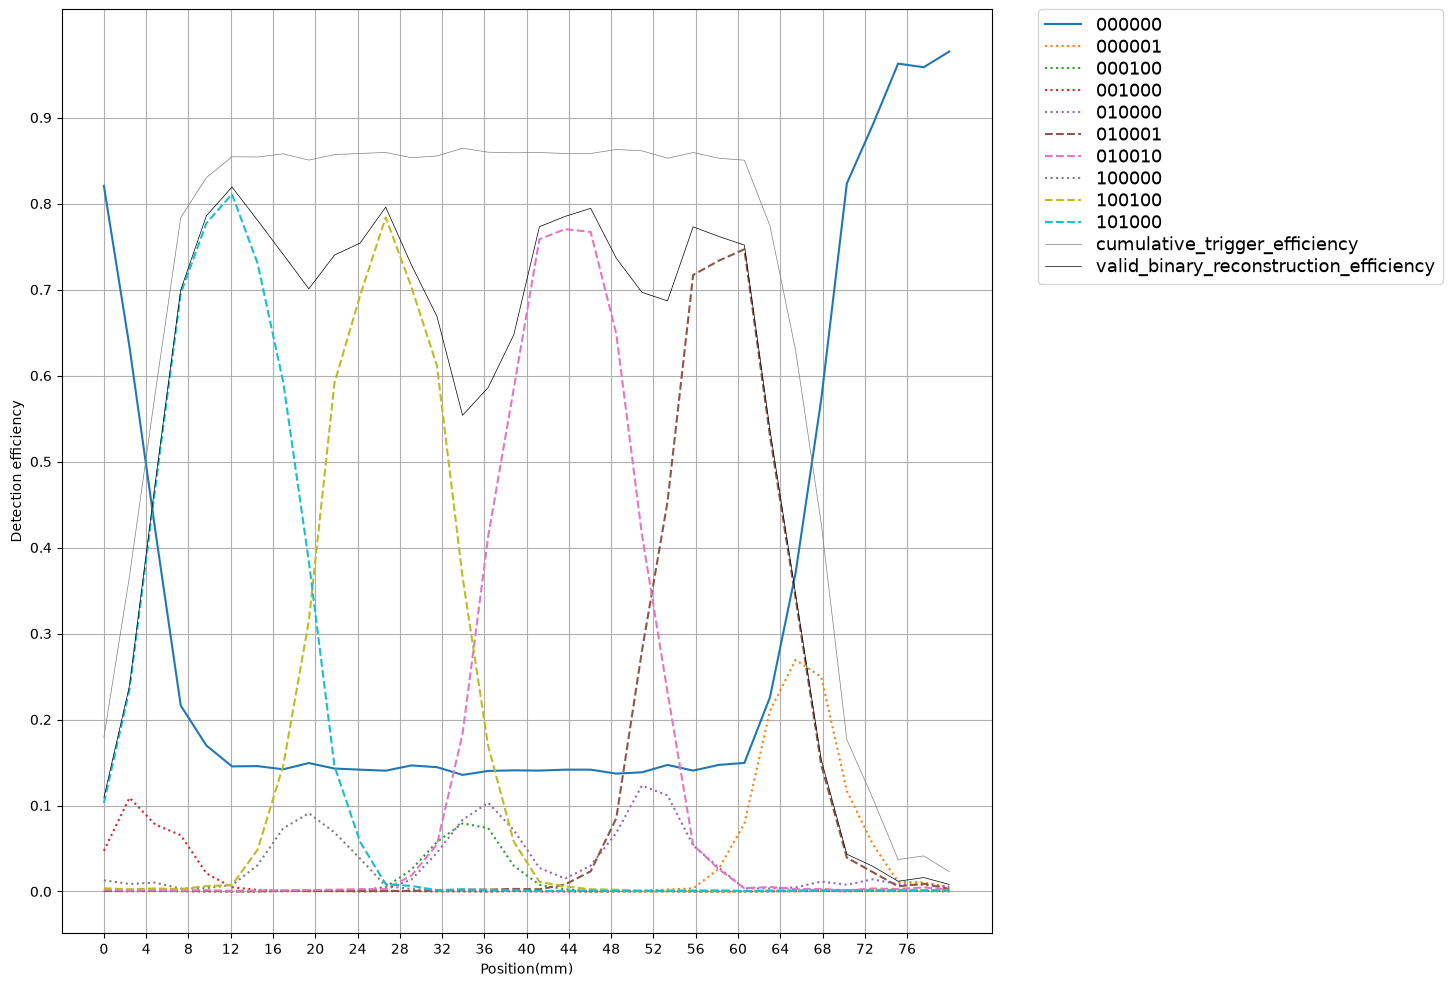

In [ ]:
#Generate x and y vertices for the data
# x = np.linspace(0,80,34 - ROYAL_FUCK_UP_FIX * 2)
x = np.linspace(0,80,k1)
plt.figure(figsize=(12, 12))


## plot top binary sensor-state trigger types
for bin_type, rate in enumerate(trigger_per_bin_type):
    if bin_type not in kept_top_bin_types:
        continue
    match bin_type.bit_count():
        case 0:
            style="solid"
        case 1:
            style="dotted"
        case 2:
            style="dashed"
        case 3:
            style="dashdot"
        case _:
            style="solid"
            
    plt.plot(x, rate, label=f"{f"{bin_type:06b}"}", linestyle=style)

# plot non-zero trigger state ratio
plt.plot(x, cumulative_trigger_efficiency, label="cumulative_trigger_efficiency", linestyle="solid", linewidth=0.5, color="grey")
# plot recontruction state ratio
plt.plot(x, valid_binary_reconstruction_efficiency, label="valid_binary_reconstruction_efficiency", linestyle="solid", linewidth=0.5, color="black")

plt.xticks(np.arange(0,80,4))
plt.yticks(np.arange(0,1,0.1))

plt.xlabel("Position(mm)")
plt.ylabel("Detection efficiency")
# plt.title("Detection efficiency at different positions")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

In [62]:
sum_at_loc = trigger_per_bin_type.T[:, 1:].sum(axis=-1)

norm_trigger_per_bin_type = np.transpose(trigger_per_bin_type.T[:, 1:] / sum_at_loc.reshape((-1, 1)))
norm_valid_binary_reconstruction_efficiency = norm_trigger_per_bin_type[np.array(valid_indices) -1].sum(axis=0)

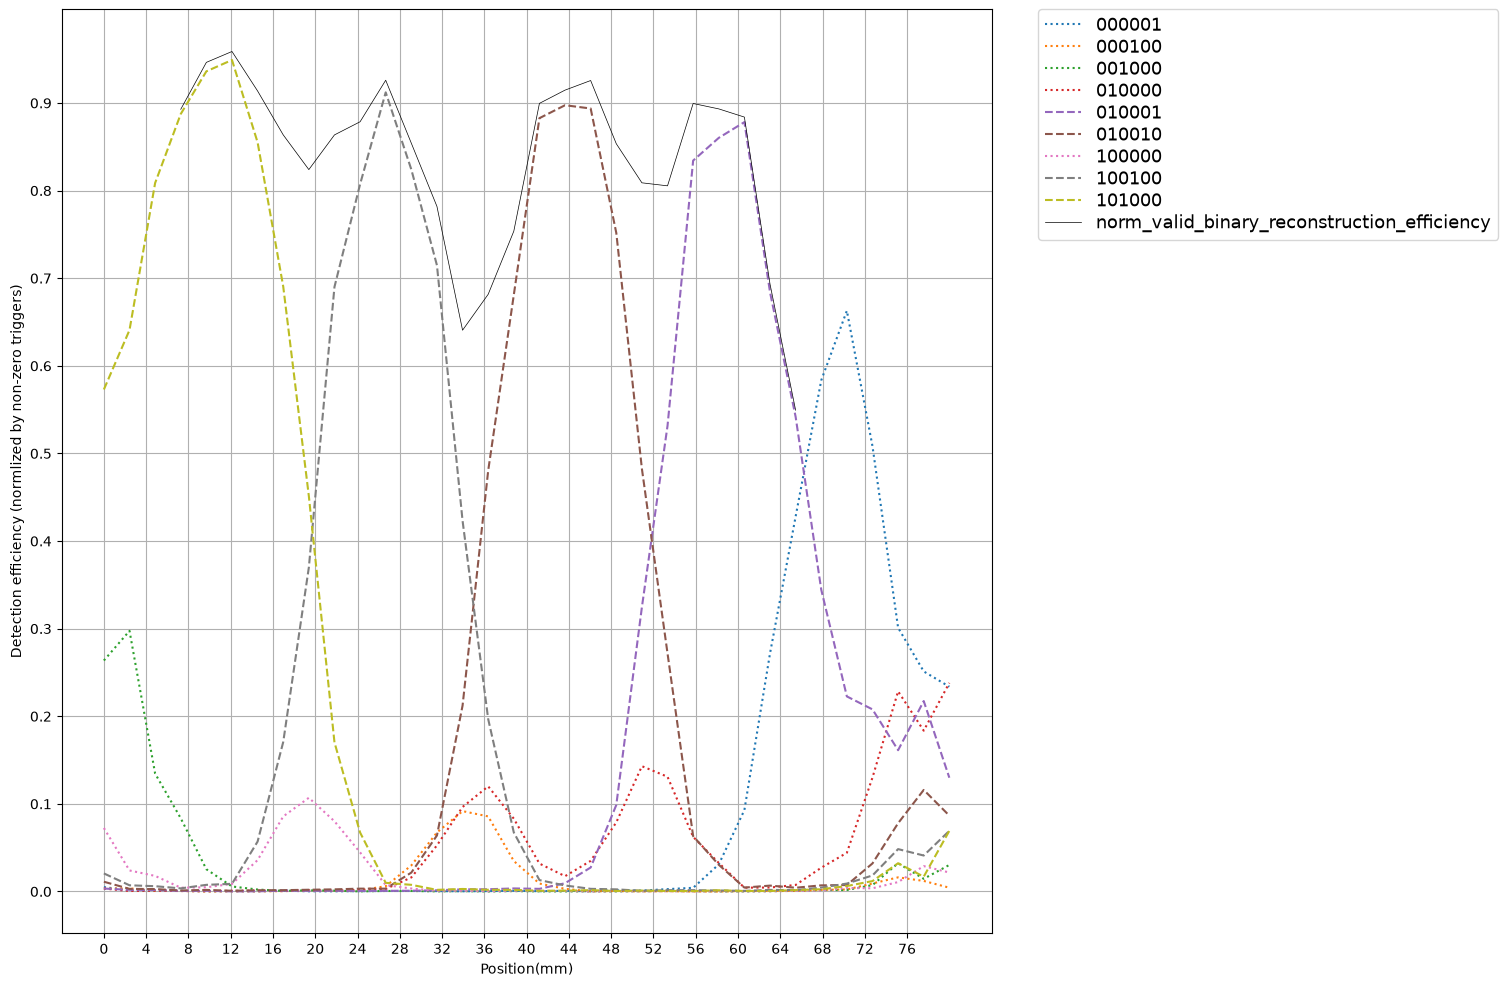

In [ ]:
#Generate x and y vertices for the data
# x = np.linspace(0,80,34 - ROYAL_FUCK_UP_FIX * 2)
x = np.linspace(0,80,k1)
plt.figure(figsize=(12, 12))


## plot top binary sensor-state trigger types
for i, rate in enumerate(norm_trigger_per_bin_type):
    bin_type = i + 1
    if bin_type not in kept_top_bin_types:
        continue
    match bin_type.bit_count():
        case 0:
            style="solid"
        case 1:
            style="dotted"
        case 2:
            style="dashed"
        case 3:
            style="dashdot"
        case _:
            style="solid"
            
    plt.plot(x, rate, label=f"{f"{bin_type:06b}"}", linestyle=style)

# plot recontruction state ratio
plt.plot(x[3:-6], norm_valid_binary_reconstruction_efficiency[3:-6], label="norm_valid_binary_reconstruction_efficiency", linestyle="solid", linewidth=0.5, color="black")

# plt.axhline(y=1)

plt.xticks(np.arange(0,80,4))
plt.yticks(np.arange(0,1,0.1))

plt.xlabel("Position(mm)")
plt.ylabel("Detection efficiency (normlized by non-zero triggers)")
# plt.title("Detection efficiency at different positions")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

## Formatted LateX Graph

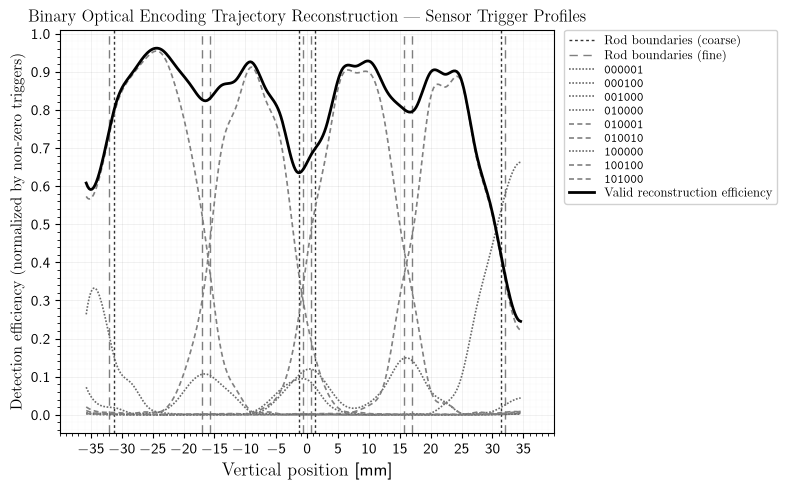

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc
from scipy.interpolate import make_interp_spline

# LaTeX and serif font setup
rc('text', usetex=True)
rc('font', family='serif')

# Define x domain and centering offset (-37.5 mm)
x = np.linspace(0, 80, k1)
x_centered = x - 35.75

# Mask boundaries to avoid edge artifacts
mask = np.abs(x_centered) < 36
x_centered_masked = x_centered[mask]
x_smooth = np.linspace(x_centered_masked.min(), x_centered_masked.max(), 300)

fig, ax = plt.subplots(figsize=(8, 5))

# Plot coarse rod boundaries (densely dotted)
coarse_lines = [-31.33, -1.33, 1.33, 31.33]
coarse_drawn = False
for xv in coarse_lines:
    label = r'Rod boundaries (coarse)' if not coarse_drawn else None
    ax.axvline(
        xv, color='black', linewidth=1.0, linestyle=(0, (2, 2)), alpha=0.8, label=label
    )
    coarse_drawn = True

# Plot fine rod boundaries (loosely dashed)
fine_lines = [
    -32.00,
    -17.00,
    -15.667,
    -0.667,
    0.667,
    15.667,
    17.00,
    32.00,
]
fine_drawn = False
for xv in fine_lines:
    label = r'Rod boundaries (fine)' if not fine_drawn else None
    ax.axvline(
        xv, color='black', linewidth=1.0, linestyle=(0, (6, 4)), alpha=0.5, label=label
    )
    fine_drawn = True

# Black & White / Grayscale linestyles and gray shades mapped by bit count
style_map = {
    0: {'ls': '-', 'color': 'black', 'lw': 1.2},
    1: {'ls': (0, (1, 1)), 'color': 'dimgray', 'lw': 1.2},
    2: {'ls': (0, (3, 2)), 'color': 'gray', 'lw': 1.2},
    3: {'ls': (0, (5, 2, 1, 2)), 'color': 'darkgray', 'lw': 1.2},
}

# Plot binary sensor-state trigger types
for i, rate in enumerate(norm_trigger_per_bin_type):
    bin_type = i + 1
    if bin_type not in kept_top_bin_types:
        continue

    rate_masked = np.array(rate)[mask]

    # Smooth curve fitting
    spline = make_interp_spline(x_centered_masked, rate_masked, k=3)
    y_smooth = spline(x_smooth)

    bit_cnt = bin_type.bit_count()
    cfg = style_map.get(bit_cnt, {'ls': '-', 'color': 'black', 'lw': 1.0})

    bit_str = f'{bin_type:06b}'
    ax.plot(
        x_smooth,
        y_smooth,
        label=rf'$\mathtt{{{bit_str}}}$',
        linestyle=cfg['ls'],
        color=cfg['color'],
        linewidth=cfg['lw'],
    )

# Plot valid binary reconstruction efficiency (prominent solid black curve)
y_rec_masked = np.array(norm_valid_binary_reconstruction_efficiency)[mask]
spline_rec = make_interp_spline(x_centered_masked, y_rec_masked, k=3)
y_rec_smooth = spline_rec(x_smooth)

ax.plot(
    x_smooth,
    y_rec_smooth,
    label=r'Valid reconstruction efficiency',
    color='black',
    linestyle='-',
    linewidth=2.0,
)

# Axis limits, ticks, and labels
ax.set_xlim(-40, 40)
ax.set_xticks(np.arange(-35, 40, 5))
ax.set_yticks(np.arange(0, 1.1, 0.1))

ax.set_xlabel(r'Vertical position $[\mathrm{mm}]$', fontsize=13)
ax.set_ylabel(
    r'Detection efficiency (normalized by non-zero triggers)', fontsize=11
)
ax.set_title(
    r'Binary Optical Encoding Trajectory Reconstruction — Sensor Trigger Profiles',
    fontsize=12,
)

# Grid and tick parameters
ax.tick_params(labelsize=11)
ax.grid(which='major', lw=0.4, ls='-', color='gray', alpha=0.2)
ax.grid(which='minor', lw=0.3, ls=':', color='gray', alpha=0.15)
ax.minorticks_on()

# Legend positioning outside or tightly integrated
ax.legend(
    fontsize=9,
    framealpha=0.9,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0,
)

fig.tight_layout()
fig.savefig('binary_reconstruction_efficiency.pdf', dpi=300, bbox_inches='tight')
fig.savefig('binary_reconstruction_efficiency.png', dpi=300, bbox_inches='tight')
plt.show()

## ADC Event Example per type.

In [73]:
valid_data = []

class ValidData:
    def __init__(self, wave, integral, tot):
        self.waveform = wave
        self.integral = integral
        self.tot = tot

for valid_i in valid_indices:
    loc = np.argwhere(trigger_no == valid_i)

    x, y = loc.T
    loc_waveforms = all_waveforms[x, y]
    loc_integrals = all_integrals[x, y]
    loc_tot = all_tot[x, y]

    print(loc_waveforms.shape)
    print(loc_integrals.shape)
    print(loc_tot.shape)

    valid_data.append(ValidData(loc_waveforms, loc_integrals, loc_tot))


(41642, 10, 924)
(41642, 10)
(41642, 10)
(49758, 10, 924)
(49758, 10)
(49758, 10)
(45517, 10, 924)
(45517, 10)
(45517, 10)
(50377, 10, 924)
(50377, 10)
(50377, 10)


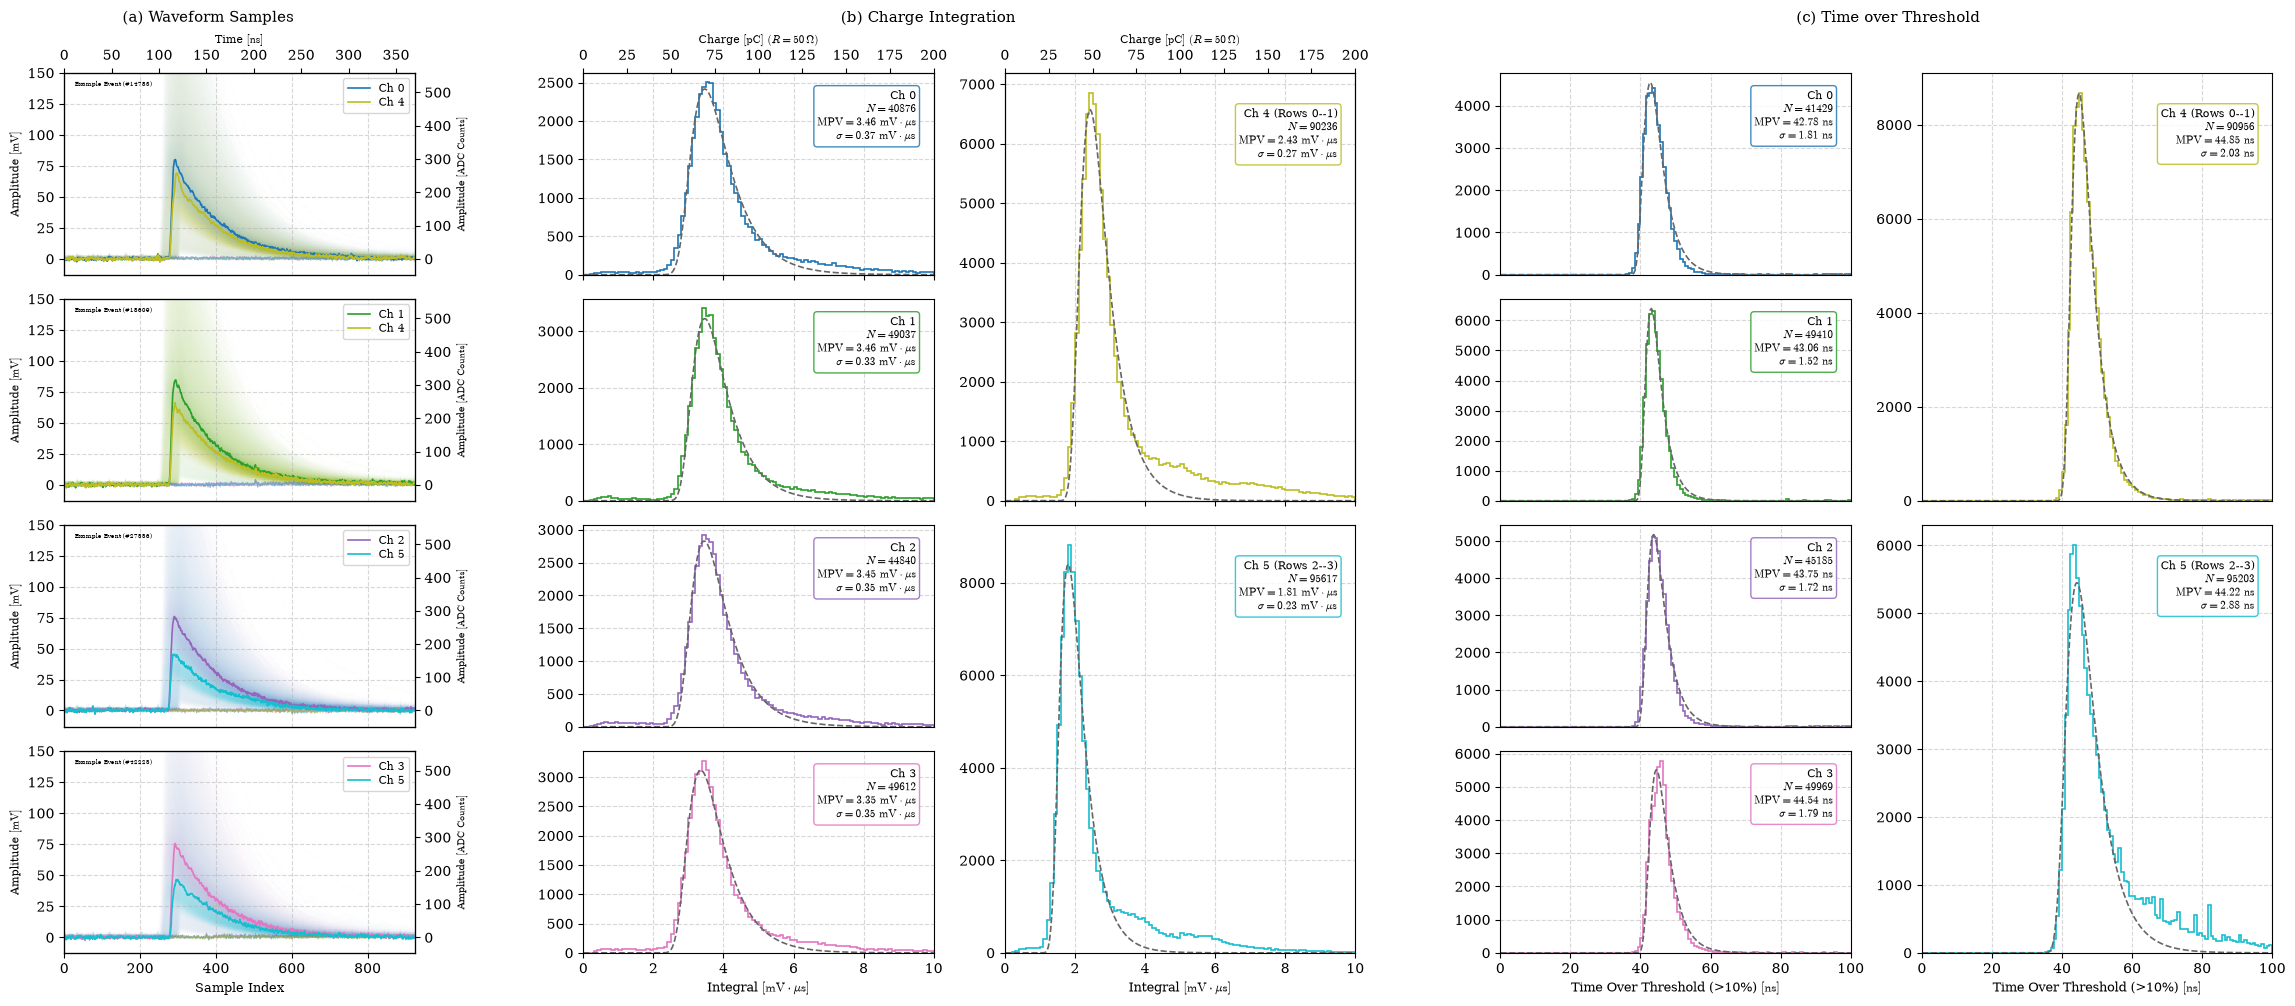

In [133]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import moyal
from scipy.optimize import curve_fit

# TeX styling in Matplotlib
plt.rcParams['text.usetex'] = False  # Set to True if local LaTeX distribution is installed
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern TeX style math font

# ===== 1. CONVERSION CONSTANTS & CONFIGURATION =====
ADC_CONVERSION = 1.1 * 1000 / (2**12)  # mV per ADC count (0.26855 mV/ADC)
TIME_PER_SAMPLE = 0.4                  # ns per sample (2.5 GS/s)
IMPEDANCE = 50.0                       # Ohms (standard signal termination)

# Adjustable x-axis bounds
X_BOUNDS_WAVE_SAMPLES = (0, 924)       # Sample Index range
X_BOUNDS_INT_CHARGE_MV_US = (0, 10)    # Integral bounds in [mV * us]
X_BOUNDS_TOT_SAMPLES = (0, 250)        # Raw ToT bounds in samples

Y_BOUND_WAVE_SAMPLES = 150

# Converted bounds for waveforms and ToT
X_BOUNDS_WAVE_NS = (X_BOUNDS_WAVE_SAMPLES[0] * TIME_PER_SAMPLE, X_BOUNDS_WAVE_SAMPLES[1] * TIME_PER_SAMPLE)
X_BOUNDS_TOT_NS  = (X_BOUNDS_TOT_SAMPLES[0] * TIME_PER_SAMPLE, X_BOUNDS_TOT_SAMPLES[1] * TIME_PER_SAMPLE)

# Bin counts
NUM_BINS_INT = 100
NUM_BINS_TOT = 125

# Layout Spacing
ROW_HSPACE = 0.12
COL_WSPACE = 0.28
# Extra gap between waveform col (0) and charge-integration block (was col 1)
WAVE_INT_GAP = 0.075
INT_TOT_GAP = 0.0075  # gap between charge-integration and ToT blocks

# Channel Color Map dynamically sampled from tab10
CHANNEL_COLORS = {
    i: col
    for i, col in enumerate(plt.cm.tab10(np.linspace(0, 1, 6)))
}

FIT_COLOR = '#666666'  # Grey for Landau Fits


# ===== 2. HELPER FUNCTIONS =====
def create_channel_cmap(color_rgb):
    """Creates a colormap fading from transparent to the channel's full color."""
    r, g, b = color_rgb[:3]
    cdict = {
        'red':   ((0.0, r, r), (1.0, r, r)),
        'green': ((0.0, g, g), (1.0, g, g)),
        'blue':  ((0.0, b, b), (1.0, b, b)),
        'alpha': ((0.0, 0.0, 0.0), (1.0, 0.9, 0.9))  # Higher max alpha for boosted visibility
    }
    return LinearSegmentedColormap('channel_alpha_cmap', cdict)


def plot_waveform_density_heatmap(ax, wave_data_ch, color_rgb, x_bounds, y_bounds=(0, 200), gamma=0.35):
    """Computes and overlays a 2D histogram heatmap up to 200 mV with gamma scaling."""
    n_events, n_samples = wave_data_ch.shape
    sample_indices = np.tile(np.arange(n_samples), n_events)
    amplitudes = wave_data_ch.ravel()

    # Define 2D histogram bins constrained to y_bounds (0 to 200 mV)
    x_bins = np.linspace(x_bounds[0], x_bounds[1], n_samples + 1)
    y_bins = np.linspace(y_bounds[0], y_bounds[1], 150)

    # Compute density within range
    H, xedges, yedges = np.histogram2d(
        sample_indices, amplitudes, bins=[x_bins, y_bins], range=[x_bounds, y_bounds]
    )
    H = H.T  # Transpose for imshow coordinate mapping

    max_count = np.max(H)
    if max_count > 0:
        H_norm = H / max_count
        H_boosted = np.power(H_norm, gamma)
    else:
        H_boosted = H

    cmap = create_channel_cmap(color_rgb)
    im = ax.imshow(
        H_boosted,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        origin='lower',
        aspect='auto',
        cmap=cmap,
        # interpolation='gaussian',
        zorder=1,
        vmin=0, vmax=1.0
    )
    
    return im, max_count


def landau_func(x, amplitude, mpv, sigma):
    return amplitude * moyal.pdf(x, loc=mpv, scale=sigma)


def plot_hist_with_landau_fit(ax, data, x_range, num_bins, color, title=None, 
                              ch_label="", show_xlabel=False, xlabel="", unit_str=""):
    data_clean = data[~np.isnan(data)]
    data_filtered = data_clean[(data_clean >= x_range[0]) & (data_clean <= x_range[1])]
    
    counts, bin_edges = np.histogram(data_filtered, bins=num_bins, range=x_range)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Histogram outline matching channel color
    ax.hist(data_filtered, bins=num_bins, range=x_range, histtype='step', 
            linewidth=1.2, color=color, label='Data')
    
    n_count = len(data_filtered)
    sample_mpv = bin_centers[np.argmax(counts)] if n_count > 0 else (x_range[0] + x_range[1]) / 2
    sample_sigma = np.std(data_filtered) / 2.0 if n_count > 0 else 1.0
    
    mpv_val, sigma_val = sample_mpv, sample_sigma
    
    # Landau Fit (Grey)
    if n_count > 5 and sample_sigma > 0:
        bin_width = bin_edges[1] - bin_edges[0]
        p0 = [np.max(counts) * bin_width * 2, sample_mpv, sample_sigma]
        try:
            popt, _ = curve_fit(
                landau_func, bin_centers, counts, p0=p0, 
                bounds=(0, [np.inf, x_range[1], (x_range[1] - x_range[0]) / 2]), 
                maxfev=2000
            )
            amp_val, mpv_val, sigma_val = popt
            
            x_fit = np.linspace(x_range[0], x_range[1], 300)
            y_fit = landau_func(x_fit, amp_val, mpv_val, sigma_val)
            ax.plot(x_fit, y_fit, color=FIT_COLOR, linestyle='--', linewidth=1.2, label='Landau Fit')
        except Exception:
            pass
            
    stats_text = (
        f"Ch {ch_label}\n"
        f"$N = {n_count}$\n"
        f"$\\mathrm{{MPV}} = {mpv_val:.2f}\\ \\mathrm{{{unit_str}}}$\n"
        f"$\\sigma = {sigma_val:.2f}\\ \\mathrm{{{unit_str}}}$"
    )
    ax.text(0.95, 0.92, stats_text, transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor=color))
    
    ax.set_xlim(x_range)
    if title:
        ax.set_title(title, fontsize=10, pad=6)
        
    if not show_xlabel:
        ax.tick_params(labelbottom=False, bottom=False)
    else:
        ax.set_xlabel(xlabel, fontsize=9)


# ===== 3. BUILD GRID & AXES =====
fig = plt.figure(figsize=(24, 11))
# ncols=7: [wave | spacer | int_left | int_right | spacer | tot_left | tot_right]
gs = fig.add_gridspec(
    nrows=4,
    ncols=7,
    hspace=ROW_HSPACE,
    wspace=COL_WSPACE,
    width_ratios=[1.0, WAVE_INT_GAP, 1.0, 1.0, INT_TOT_GAP, 1.0, 1.0],
)

left_channels = [0, 1, 2, 3]

# Create axes for Left Columns
ax_wave = [fig.add_subplot(gs[r, 0]) for r in range(4)]

ax_int_left = []
for r in range(4):
    ax = fig.add_subplot(gs[r, 2], sharex=ax_int_left[0] if r > 0 else None)
    ax_int_left.append(ax)

ax_tot_left = []
for r in range(4):
    ax = fig.add_subplot(gs[r, 5], sharex=ax_tot_left[0] if r > 0 else None)
    ax_tot_left.append(ax)

# Combined axes for Right Columns
ax_int_right_top = fig.add_subplot(gs[0:2, 3])
ax_int_right_bot = fig.add_subplot(gs[2:4, 3], sharex=ax_int_right_top)

ax_tot_right_top = fig.add_subplot(gs[0:2, 6])
ax_tot_right_bot = fig.add_subplot(gs[2:4, 6], sharex=ax_tot_right_top)


# ===== 4. PLOT LEFT COLUMNS (ROWS 0-3) =====
for r in range(4):
    idx_val = valid_indices[r]
    data = valid_data[r]
    ch_left = left_channels[r]
    ch_color = CHANNEL_COLORS[ch_left]
    is_bottom = (r == 3)
    
    # Paired channel for this row (Ch 4 for Rows 0-1, Ch 5 for Rows 2-3)
    ch_paired = 4 if r < 2 else 5
    implicated_channels = {ch_left, ch_paired}

    # --- Waveforms & Density Heatmap (Col 0) ---
    mean_waveforms = np.mean(data.waveform, axis=0)

    # 1. Overlay Heatmap for active/implicated channels (zorder=1)
    for ch in implicated_channels:
        wave_ch = data.waveform[:, ch, :]  # Shape: (N_events, N_samples)
        plot_waveform_density_heatmap(
            ax_wave[r], wave_ch, CHANNEL_COLORS[ch], X_BOUNDS_WAVE_SAMPLES
        )

    # 2. Find the single event index closest to the mean waveform across active channels
    # Shape of waveform: (N_events, N_channels, N_samples)
    mean_waveforms = np.mean(data.waveform, axis=0)  # Shape: (N_channels, N_samples)

    # Flatten the channels for distance calculation across all active/implicated channels
    active_ch_list = list(implicated_channels)
    events_active = data.waveform[:, active_ch_list, :]  # Shape: (N_events, N_active_channels, N_samples)
    mean_active = mean_waveforms[active_ch_list, :]       # Shape: (N_active_channels, N_samples)

    # Calculate L2 distance (Euclidean norm) for each event relative to the mean
    distances = np.linalg.norm(events_active - mean_active, axis=(1, 2))
    best_event_idx = np.argmin(distances)

    # 3. Draw the Representative Event Waveforms for ALL channels (zorder=3)
    for ch in range(6):
        # Draw implicated channels with full opacity/brighter style
        if ch in implicated_channels:
            label_str = f'Ch {ch}'
            ax_wave[r].plot(
                data.waveform[best_event_idx, ch, :],
                label=label_str,
                color=CHANNEL_COLORS[ch],
                linewidth=1.2,
                alpha=1.0,
                zorder=3
            )
        # Draw non-implicated channels as subtle background context
        else:
            ax_wave[r].plot(
                data.waveform[best_event_idx, ch, :],
                color=CHANNEL_COLORS[ch],
                linewidth=0.8,
                alpha=0.35,
                zorder=2
            )
    ax_wave[r].text(
        0.03, 0.96, f"Example Event (#{best_event_idx})",
        transform=ax_wave[r].transAxes,
        ha='left', va='top', fontsize=4,
        # bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='#cccccc', linewidth=0.8),
        zorder=5
    )

    ax_wave[r].set_xlim(X_BOUNDS_WAVE_SAMPLES)
    ax_wave[r].legend(loc='upper right', fontsize=8)
    
    # Left Y-Axis: Amplitude in mV
    ax_wave[r].set_ylabel("Amplitude $[\\mathrm{mV}]$", fontsize=8)
    ax_wave[r].set_ylim(top=Y_BOUND_WAVE_SAMPLES)

    # Right Y-Axis: Amplitude in ADC Counts
    ax_adc = ax_wave[r].twinx()
    y_min, y_max = ax_wave[r].get_ylim()
    ax_adc.set_ylim(y_min / ADC_CONVERSION, y_max / ADC_CONVERSION)
    ax_adc.set_ylabel("Amplitude $[\\mathrm{ADC\\ Counts}]$", fontsize=7)
    
    # Second X-Axis (Time in ns for Waveform)
    ax_time_top = ax_wave[r].twiny()
    ax_time_top.set_xlim(X_BOUNDS_WAVE_NS)
    if r == 0:
        ax_time_top.set_xlabel("Time $[\\mathrm{ns}]$", fontsize=8, labelpad=4)
    else:
        ax_time_top.tick_params(labeltop=False, top=False)
    
    # Suppress interior ticks and tick labels
    if not is_bottom:
        ax_wave[r].tick_params(labelbottom=False, bottom=False)
    else:
        ax_wave[r].set_xlabel("Sample Index", fontsize=9)

    # --- Integral Left (Col 1) ---
    int_left_mv_us = data.integral[:, ch_left].ravel()
    plot_hist_with_landau_fit(
        ax_int_left[r], int_left_mv_us, x_range=X_BOUNDS_INT_CHARGE_MV_US, num_bins=NUM_BINS_INT,
        color=ch_color, title=None, ch_label=ch_left,
        show_xlabel=is_bottom, xlabel="Integral $[\\mathrm{mV}\\cdot\\mu\\mathrm{s}]$", unit_str="\\mathrm{mV}\\cdot\\mu\\mathrm{s}"
    )

    # Add Twin Top Axis for Charge in Coulombs (pC) on the top plot (Col 1)
    if r == 0:
        ax_pc_top = ax_int_left[0].twiny()
        ax_pc_top.set_xlim(X_BOUNDS_INT_CHARGE_MV_US[0] * (1000.0 / IMPEDANCE), 
                           X_BOUNDS_INT_CHARGE_MV_US[1] * (1000.0 / IMPEDANCE))
        ax_pc_top.set_xlabel("Charge $[\\mathrm{pC}]\\ (R = 50\\,\\Omega)$", fontsize=8, labelpad=4)

    # --- ToT Left (Col 3) ---
    tot_left_ns = data.tot[:, ch_left].ravel() * TIME_PER_SAMPLE
    plot_hist_with_landau_fit(
        ax_tot_left[r], tot_left_ns, x_range=X_BOUNDS_TOT_NS, num_bins=NUM_BINS_TOT,
        color=ch_color, title=None, ch_label=ch_left,
        show_xlabel=is_bottom, xlabel="Time Over Threshold (>10%) $[\\mathrm{ns}]$", unit_str="\\mathrm{ns}"
    )


# ===== 5. PLOT COMBINED RIGHT COLUMNS =====
# Combine Right Channel Data
int_ch4_mv_us = np.concatenate([valid_data[0].integral[:, 4].ravel(), valid_data[1].integral[:, 4].ravel()])
int_ch5_mv_us = np.concatenate([valid_data[2].integral[:, 5].ravel(), valid_data[3].integral[:, 5].ravel()])

tot_ch4_ns = np.concatenate([valid_data[0].tot[:, 4].ravel(), valid_data[1].tot[:, 4].ravel()]) * TIME_PER_SAMPLE
tot_ch5_ns = np.concatenate([valid_data[2].tot[:, 5].ravel(), valid_data[3].tot[:, 5].ravel()]) * TIME_PER_SAMPLE

color_ch4 = CHANNEL_COLORS[4]
color_ch5 = CHANNEL_COLORS[5]

# --- Integral Right (Col 2) ---
plot_hist_with_landau_fit(
    ax_int_right_top, int_ch4_mv_us, x_range=X_BOUNDS_INT_CHARGE_MV_US, num_bins=NUM_BINS_INT,
    color=color_ch4, title=None, ch_label='4 (Rows 0--1)', show_xlabel=False, unit_str="\\mathrm{mV}\\cdot\\mu\\mathrm{s}"
)
plot_hist_with_landau_fit(
    ax_int_right_bot, int_ch5_mv_us, x_range=X_BOUNDS_INT_CHARGE_MV_US, num_bins=NUM_BINS_INT,
    color=color_ch5, title=None, ch_label='5 (Rows 2--3)', show_xlabel=True, 
    xlabel="Integral $[\\mathrm{mV}\\cdot\\mu\\mathrm{s}]$", unit_str="\\mathrm{mV}\\cdot\\mu\\mathrm{s}"
)

# Add Twin Top Axis for Charge in Coulombs (pC) on Col 2
ax_pc_top_col2 = ax_int_right_top.twiny()
ax_pc_top_col2.set_xlim(X_BOUNDS_INT_CHARGE_MV_US[0] * (1000.0 / IMPEDANCE), 
                        X_BOUNDS_INT_CHARGE_MV_US[1] * (1000.0 / IMPEDANCE))
ax_pc_top_col2.set_xlabel("Charge $[\\mathrm{pC}]\\ (R = 50\\,\\Omega)$", fontsize=8, labelpad=4)


# --- ToT Right (Col 4) ---
plot_hist_with_landau_fit(
    ax_tot_right_top, tot_ch4_ns, x_range=X_BOUNDS_TOT_NS, num_bins=NUM_BINS_TOT,
    color=color_ch4, title=None, ch_label='4 (Rows 0--1)', show_xlabel=False, unit_str="\\mathrm{ns}"
)
plot_hist_with_landau_fit(
    ax_tot_right_bot, tot_ch5_ns, x_range=X_BOUNDS_TOT_NS, num_bins=NUM_BINS_TOT,
    color=color_ch5, title=None, ch_label='5 (Rows 2--3)', show_xlabel=True, 
    xlabel="Time Over Threshold (>10%) $[\\mathrm{ns}]$", unit_str="\\mathrm{ns}"
)


# ===== 6. COLUMN HEADERS & FORMATTING =====
# Super-Titles for Columns
title_y = 0.93
fig.text(0.10, title_y, "(a) Waveform Samples", fontsize=11, ha='center', va='center')
fig.text(0.40, title_y, "(b) Charge Integration", fontsize=11, ha='center', va='center')
fig.text(0.80, title_y, "(c) Time over Threshold", fontsize=11, ha='center', va='center')

# Grid lines
all_axes = ax_wave + ax_int_left + ax_tot_left + [
    ax_int_right_top, ax_int_right_bot, ax_tot_right_top, ax_tot_right_bot
]
for ax in all_axes:
    ax.grid(True, linestyle='--', alpha=0.5)

fig.subplots_adjust(hspace=ROW_HSPACE, wspace=COL_WSPACE, top=0.88, bottom=0.08, left=0.04, right=0.96)
plt.savefig('valid_data_latex_units.svg', dpi=300)
plt.show()


## Possibility Map

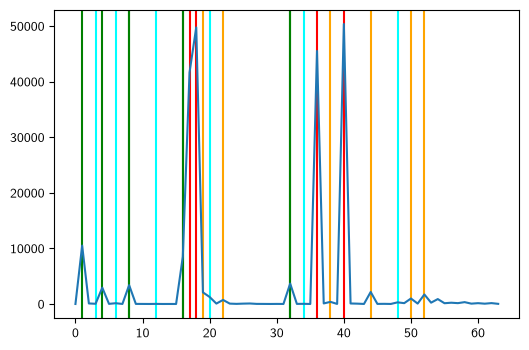

In [75]:
uniques, counts = np.unique(trigger_no, return_counts=True)

uniques.shape


single_failures = [
    0b010000,
    0b000001,

    0b010000,
    0b000100,
    0b001000,
    0b100000,

    0b001000,
    0b100000,
]

dual_failures = [
    0b000011,

    0b010100,
    0b110000,
    0b000110,
    0b100010,

    0b001100,
]

triple_failures = [
    0b010011,

    0b010110,
    0b110010,
    0b110100,
    0b100110,

    0b101100,
]


x = np.arange(0, 64)
y = np.zeros(64)
y[uniques] = counts
y[0] = 0

for i in valid_indices:
    plt.axvline(x=i, color="red")
for i in single_failures:
    plt.axvline(x=i, color="green")
for i in dual_failures:
    plt.axvline(x=i, color="aqua")
for i in triple_failures:
    plt.axvline(x=i, color="orange")

plt.plot(x, y)
plt.show()

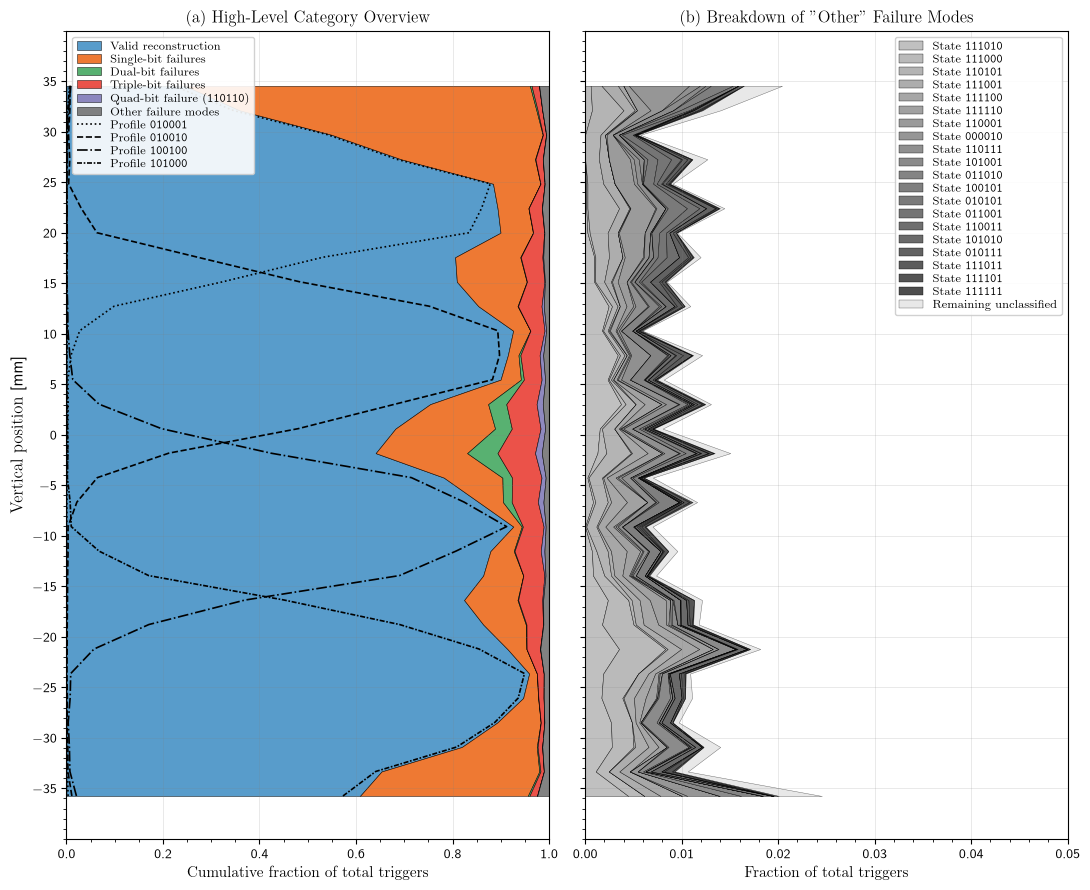

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

# LaTeX and serif font setup
rc('text', usetex=True)
rc('font', family='serif')

# Define x domain and centering offset (-35.75 mm)
x = np.linspace(0, 80, k1)
x_centered = x - 35.75

# Mask boundaries to avoid edge artifacts
mask = np.abs(x_centered) < 36
y_pos = x_centered[mask]  # Vertical position array

# Calculate normalized trigger arrays (unmasked raw slice)
sum_at_loc = trigger_per_bin_type.T[:, 1:].sum(axis=-1)
norm_trigger_per_bin_type = np.transpose(
    trigger_per_bin_type.T[:, 1:] / sum_at_loc.reshape((-1, 1))
)

# Convert bitmask lists to sets and 0-based indices
single_set = set(single_failures)
dual_set = set(dual_failures)
triple_set = set(triple_failures)
quad_set = {0b110110}
valid_set = set(valid_indices)

already_categorized = valid_set | single_set | dual_set | triple_set | quad_set
all_states = set(range(1, 64))
other_states = list(all_states - already_categorized)

# Zero-based matrix indices
valid_idx = [b - 1 for b in valid_set]
single_idx = [b - 1 for b in single_set]
dual_idx = [b - 1 for b in dual_set]
triple_idx = [b - 1 for b in triple_set]
quad_idx = [b - 1 for b in quad_set]
other_idx = [b - 1 for b in other_states]

# Create 1x2 side-by-side subplot layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 9), sharey=True)

# Helper function to compute group rate safely
def get_rate(indices):
    return norm_trigger_per_bin_type[indices].sum(axis=0)[mask] if indices else np.zeros_like(y_pos)

# Helper for sub-state gradient colors
def get_gradient_colors(cmap, n):
    if n == 1:
        return [cmap(0.6)]
    return [cmap(val) for val in np.linspace(0.4, 0.85, n)]

# ==============================================================================
# LEFT COLUMN: High-Level Overview
# ==============================================================================
overview_groups = [
    ('Valid reconstruction', valid_idx, plt.cm.Blues),
    ('Single-bit failures', single_idx, plt.cm.Oranges),
    ('Dual-bit failures', dual_idx, plt.cm.Greens),
    ('Triple-bit failures', triple_idx, plt.cm.Reds),
    (r'Quad-bit failure ($\mathtt{110110}$)', quad_idx, plt.cm.Purples),
    ('Other failure modes', other_idx, plt.cm.Greys),
]

c_curr1 = np.zeros_like(y_pos)

for label, indices, cmap in overview_groups:
    rate = get_rate(indices)
    c_next = c_curr1 + rate
    color = cmap(0.65)  # Solid family base color for summary

    ax1.fill_betweenx(
        y_pos,
        c_curr1,
        c_next,
        color=color,
        alpha=0.85,
        edgecolor='black',
        linewidth=0.4,
        label=label,
    )
    c_curr1 = c_next

# Dotted overlay curves for individual valid profiles
valid_linestyles = [':', '--', '-.', (0, (3, 1, 1, 1))]
for i, idx in enumerate(sorted(list(valid_set))):
    bit_str = f'{idx:06b}'
    rate = norm_trigger_per_bin_type[idx - 1][mask]
    ax1.plot(
        rate,
        y_pos,
        color='black',
        linestyle=valid_linestyles[i % len(valid_linestyles)],
        linewidth=1.2,
        label=rf'Profile $\mathtt{{{bit_str}}}$',
    )

ax1.set_xlim(0, 1.0)
ax1.set_xticks(np.arange(0, 1.1, 0.2))
ax1.set_ylabel(r'Vertical position $[\mathrm{mm}]$', fontsize=12)
ax1.set_xlabel(r'Cumulative fraction of total triggers', fontsize=11)
ax1.set_title(r'(a) High-Level Category Overview', fontsize=12)
ax1.grid(which='major', lw=0.4, ls='-', color='gray', alpha=0.3)
ax1.minorticks_on()
ax1.legend(fontsize=8.5, framealpha=0.9, loc='upper left')

# ==============================================================================
# RIGHT COLUMN: Breakdown of "Other" Failure Modes
# ==============================================================================
# Sort "Other" sub-states by overall integrated yield
other_sorted = sorted(
    other_states,
    key=lambda b: norm_trigger_per_bin_type[b - 1][mask].sum(),
    reverse=True,
)

# Select top individual sub-states to isolate, grouping residual into "Remainder"
TOP_N_OTHER = 20
top_other_states = other_sorted[:TOP_N_OTHER]
remainder_other_states = other_sorted[TOP_N_OTHER:]

c_curr2 = np.zeros_like(y_pos)

# 1. Color gradient breakdown for top "Other" sub-states
other_colors = get_gradient_colors(plt.cm.Greys, len(top_other_states))

for b, color in zip(top_other_states, other_colors):
    bit_str = f'{b:06b}'
    rate = norm_trigger_per_bin_type[b - 1][mask]
    c_next = c_curr2 + rate

    ax2.fill_betweenx(
        y_pos,
        c_curr2,
        c_next,
        color=color,
        alpha=0.85,
        edgecolor='black',
        linewidth=0.3,
        label=rf'State $\mathtt{{{bit_str}}}$',
    )
    c_curr2 = c_next

# 2. Residual remainder of "Other"
if remainder_other_states:
    rem_indices = [b - 1 for b in remainder_other_states]
    rate = get_rate(rem_indices)
    c_next = c_curr2 + rate

    ax2.fill_betweenx(
        y_pos,
        c_curr2,
        c_next,
        color='#d9d9d9',
        alpha=0.6,
        edgecolor='black',
        linewidth=0.3,
        label=r'Remaining unclassified',
    )

# Right axis settings (rescaled x-axis to zoom into "Other" fraction scale)
max_other_frac = norm_trigger_per_bin_type[other_idx].sum(axis=0)[mask].max() * 1.15
ax2.set_xlim(0, max(max_other_frac, 0.05))
ax2.set_ylim(-40, 40)
ax2.set_yticks(np.arange(-35, 40, 5))
ax2.set_xlabel(r'Fraction of total triggers', fontsize=11)
ax2.set_title(r'(b) Breakdown of "Other" Failure Modes', fontsize=12)
ax2.grid(which='major', lw=0.4, ls='-', color='gray', alpha=0.3)
ax2.minorticks_on()
ax2.legend(fontsize=8.5, framealpha=0.9, loc='upper right')

fig.tight_layout()
plt.show()

In [71]:
import numpy as np
from scipy.ndimage import label

# Define 4-connectivity structure (Up, Down, Left, Right)
STRUCTURE_4 = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])

def get_6bit_grid(v6):
    """Constructs the 4x2 grid for a 6-bit integer."""
    grid = np.ones((4, 2), dtype=int)
    
    # Left column (x=0)
    if v6 & 0b010000:
        grid[0, 0] = 0
        grid[1, 0] = 0
    if v6 & 0b100000:
        grid[2, 0] = 0
        grid[3, 0] = 0
        
    # Right column (x=1)
    if v6 & 0b000001:
        grid[0, 1] = 0
    if v6 & 0b000010:
        grid[1, 1] = 0
    if v6 & 0b000100:
        grid[2, 1] = 0
    if v6 & 0b001000:
        grid[3, 1] = 0
        
    return grid

contiguous_list = []
disjointed_list = []

# Classify all 64 binary states (0..63)
for v6 in range(64):
    grid = get_6bit_grid(v6)
    black_pixels = (grid == 0).astype(int)
    
    # Label connected components using orthogonal adjacency
    _, num_components = label(black_pixels, structure=STRUCTURE_4)
    
    if num_components == 1:
        contiguous_list.append(v6)
    elif num_components > 1:
        disjointed_list.append(v6)

# Convert lists to int32 NumPy ndarrays
contiguous_array = np.array(contiguous_list, dtype=np.int32)
disjointed_array = np.array(disjointed_list, dtype=np.int32)

# Output summary
print(f"Contiguous Array (shape={contiguous_array.shape}, dtype={contiguous_array.dtype}):")
print(contiguous_array)

print(f"\nDisjointed Array (shape={disjointed_array.shape}, dtype={disjointed_array.dtype}):")
print(disjointed_array)

Contiguous Array (shape=(42,), dtype=int32):
[ 1  2  3  4  6  7  8 12 14 15 16 17 18 19 22 23 30 31 32 36 38 39 40 44
 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63]

Disjointed Array (shape=(21,), dtype=int32):
[ 5  9 10 11 13 20 21 24 25 26 27 28 29 33 34 35 37 41 42 43 45]


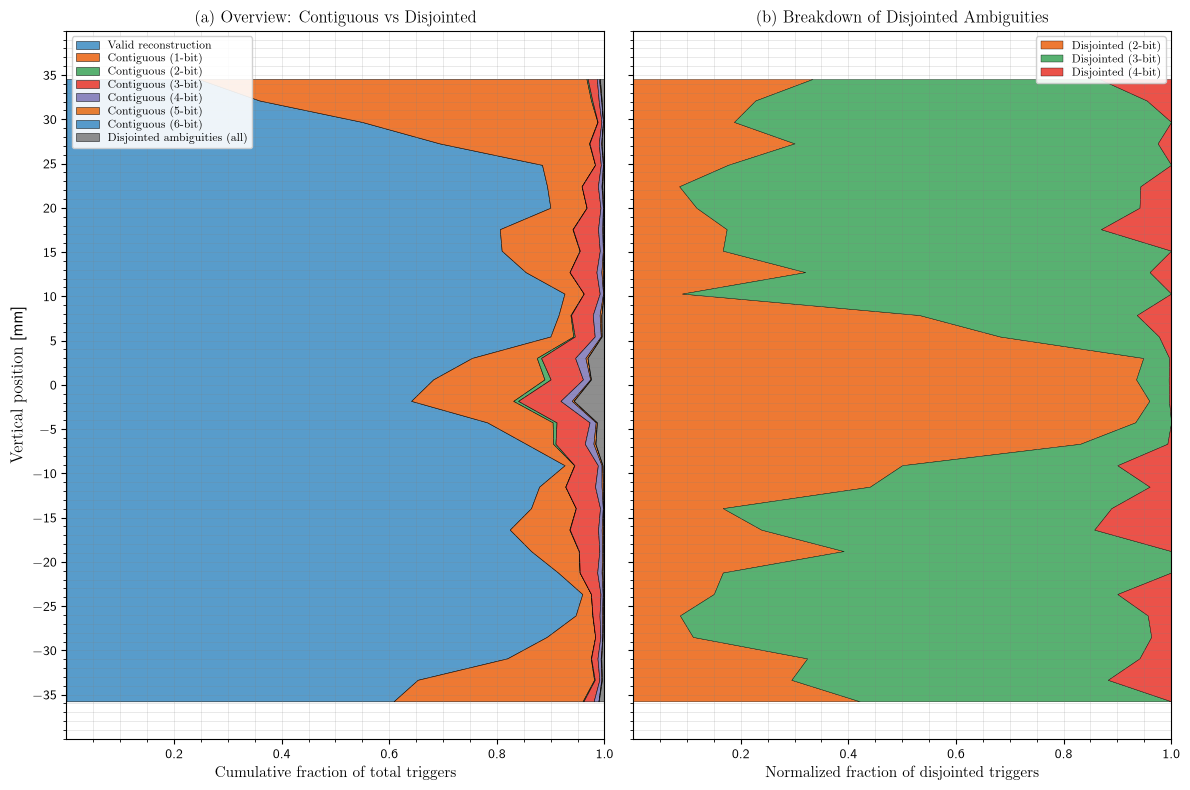

In [78]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

try:
    from scipy.ndimage import label as label_components
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

# LaTeX and serif font setup
rc('text', usetex=True)
rc('font', family='serif')

# Define x domain and centering offset (-35.75 mm)
x = np.linspace(0, 80, k1)
x_centered = x - 35.75

# Mask boundaries to avoid edge artifacts
mask = np.abs(x_centered) < 36
y_pos = x_centered[mask]  # Vertical position array

# Calculate normalized trigger arrays
sum_at_loc = trigger_per_bin_type.T[:, 1:].sum(axis=-1)
norm_trigger_per_bin_type = np.transpose(
    trigger_per_bin_type.T[:, 1:] / sum_at_loc.reshape((-1, 1))
)

# ==============================================================================
# Helper Functions: Connectivity & 4x2 Grid Representation
# ==============================================================================
STRUCTURE_4 = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])

def is_contiguous_state(v6):
    """Returns True if state has exactly 1 orthogonally contiguous active region."""
    if v6 == 0:
        return False
    
    grid = np.ones((4, 2), dtype=int)
    if v6 & 0b010000: grid[0, 0] = grid[1, 0] = 0
    if v6 & 0b100000: grid[2, 0] = grid[3, 0] = 0
    if v6 & 0b000001: grid[0, 1] = 0
    if v6 & 0b000010: grid[1, 1] = 0
    if v6 & 0b000100: grid[2, 1] = 0
    if v6 & 0b001000: grid[3, 1] = 0
    
    black_pixels = (grid == 0).astype(int)
    
    if HAS_SCIPY:
        _, num_c = label_components(black_pixels, structure=STRUCTURE_4)
        return num_c == 1
    else:
        # Fallback BFS for 4-connectivity
        visited = np.zeros_like(black_pixels, dtype=bool)
        components = 0
        for r in range(4):
            for c in range(2):
                if black_pixels[r, c] and not visited[r, c]:
                    components += 1
                    q = [(r, c)]
                    visited[r, c] = True
                    while q:
                        cr, cc = q.pop(0)
                        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                            nr, nc = cr + dr, cc + dc
                            if 0 <= nr < 4 and 0 <= nc < 2:
                                if black_pixels[nr, nc] and not visited[nr, nc]:
                                    visited[nr, nc] = True
                                    q.append((nr, nc))
        return components == 1

# ==============================================================================
# Categorization & Bit-Count Grouping
# ==============================================================================
valid_set = set(valid_indices)
all_states = set(range(1, 64))
ambiguity_states = all_states - valid_set

# Group contiguous vs disjointed states by active bit count (popcount)
contiguous_by_bits = {b: [] for b in range(1, 7)}
disjointed_by_bits = {b: [] for b in range(1, 7)}

for v6 in sorted(list(ambiguity_states)):
    bit_count = bin(v6).count('1')
    if is_contiguous_state(v6):
        contiguous_by_bits[bit_count].append(v6 - 1)  # 0-based index
    else:
        disjointed_by_bits[bit_count].append(v6 - 1)  # 0-based index

valid_idx = [b - 1 for b in valid_set]
all_disjointed_idx = [idx for bit_list in disjointed_by_bits.values() for idx in bit_list]

# Create 1x2 side-by-side subplot layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

def get_rate(indices):
    return norm_trigger_per_bin_type[indices].sum(axis=0)[mask] if indices else np.zeros_like(y_pos)

# ==============================================================================
# LEFT COLUMN: Reconstructions, Contiguous (by Bits), & Disjointed
# ==============================================================================
c_curr1 = np.zeros_like(y_pos)

# 1. Valid reconstruction
valid_rate = get_rate(valid_idx)
c_next1 = c_curr1 + valid_rate
ax1.fill_betweenx(
    y_pos, c_curr1, c_next1,
    color=plt.cm.Blues(0.65), alpha=0.85, edgecolor='black', linewidth=0.4,
    label=r'Valid reconstruction'
)
c_curr1 = c_next1

# 2. Contiguous Ambiguities grouped by active bit count
contig_cmaps = [plt.cm.Oranges, plt.cm.Greens, plt.cm.Reds, plt.cm.Purples, plt.cm.YlOrBr, plt.cm.Blues]
for b_count in range(1, 7):
    indices = contiguous_by_bits[b_count]
    if not indices:
        continue
    rate = get_rate(indices)
    c_next1 = c_curr1 + rate
    cmap = contig_cmaps[(b_count - 1) % len(contig_cmaps)]
    
    ax1.fill_betweenx(
        y_pos, c_curr1, c_next1,
        color=cmap(0.65), alpha=0.85, edgecolor='black', linewidth=0.4,
        label=rf'Contiguous ({b_count}-bit)'
    )
    c_curr1 = c_next1

# 3. Disjointed Ambiguities Group
disjointed_rate = get_rate(all_disjointed_idx)
c_next1 = c_curr1 + disjointed_rate
ax1.fill_betweenx(
    y_pos, c_curr1, c_next1,
    color=plt.cm.Greys(0.6), alpha=0.85, edgecolor='black', linewidth=0.4,
    label=r'Disjointed ambiguities (all)'
)

# Left Column Formatting (Log Scale)
# ax1.set_xscale('log')
ax1.set_xlim(1e-4, 1.0)
ax1.set_ylabel(r'Vertical position $[\mathrm{mm}]$', fontsize=12)
ax1.set_xlabel(r'Cumulative fraction of total triggers', fontsize=11)
ax1.set_title(r'(a) Overview: Contiguous vs Disjointed', fontsize=12)
ax1.grid(which='both', lw=0.4, ls='-', color='gray', alpha=0.3)
ax1.minorticks_on()
ax1.legend(fontsize=8, framealpha=0.9, loc='upper left')

# ==============================================================================
# RIGHT COLUMN: Normalized Disjointed Breakdown (by Bit Count)
# ==============================================================================
# Compute total disjointed profile across position y_pos for normalization
total_disjointed_profile = norm_trigger_per_bin_type[all_disjointed_idx].sum(axis=0)[mask]
# Prevent divide-by-zero if total_disjointed_profile is zero
safe_norm = np.where(total_disjointed_profile > 0, total_disjointed_profile, 1.0)

c_curr2 = np.zeros_like(y_pos)
disjointed_cmaps = [plt.cm.Blues, plt.cm.Oranges, plt.cm.Greens, plt.cm.Reds, plt.cm.Purples, plt.cm.BrBG]

for b_count in range(1, 7):
    indices = disjointed_by_bits[b_count]
    if not indices:
        continue
    
    # Normalize disjointed rates to range [0, 1]
    raw_rate = get_rate(indices)
    norm_disjointed_rate = raw_rate / safe_norm
    c_next2 = c_curr2 + norm_disjointed_rate
    cmap = disjointed_cmaps[(b_count - 1) % len(disjointed_cmaps)]
    
    ax2.fill_betweenx(
        y_pos, c_curr2, c_next2,
        color=cmap(0.65), alpha=0.85, edgecolor='black', linewidth=0.3,
        label=rf'Disjointed ({b_count}-bit)'
    )
    c_curr2 = c_next2

# Right Column Formatting (Log Scale, Range 0 to 1)
# ax2.set_xscale('log')
ax2.set_xlim(1e-4, 1.0)
ax2.set_ylim(-40, 40)
ax2.set_yticks(np.arange(-35, 40, 5))
ax2.set_xlabel(r'Normalized fraction of disjointed triggers', fontsize=11)
ax2.set_title(r'(b) Breakdown of Disjointed Ambiguities', fontsize=12)
ax2.grid(which='both', lw=0.4, ls='-', color='gray', alpha=0.3)
ax2.minorticks_on()
ax2.legend(fontsize=8, framealpha=0.9, loc='upper right')

fig.tight_layout()
plt.show()

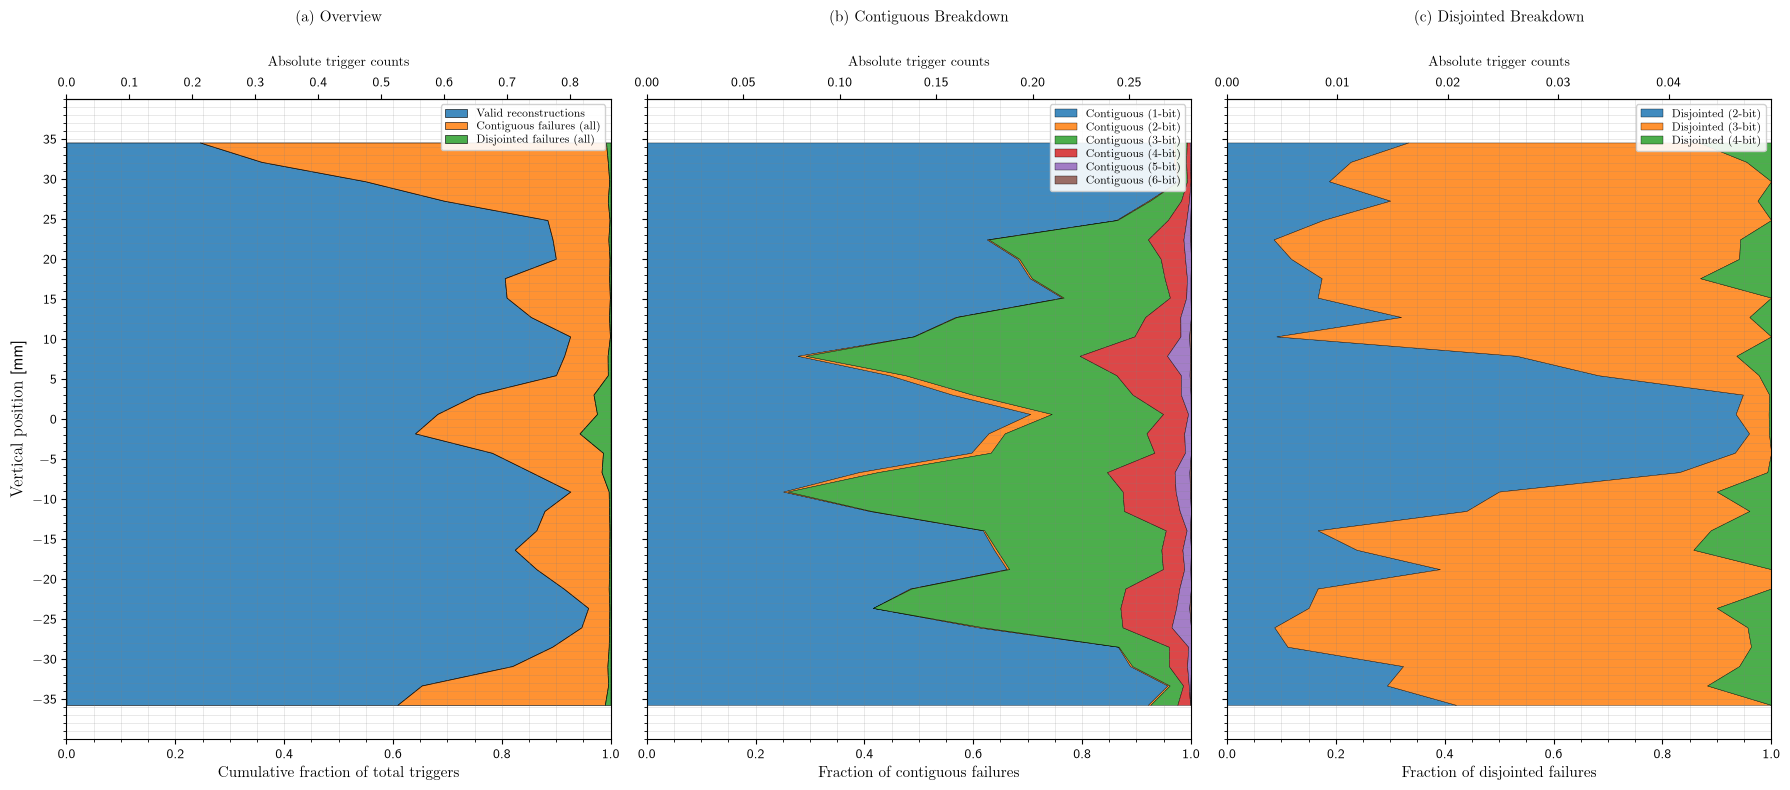

In [79]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

try:
    from scipy.ndimage import label as label_components
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

# LaTeX and serif font setup
rc('text', usetex=True)
rc('font', family='serif')

# ==============================================================================
# Domain & Data Setup (Spatial & Normalization Slicing)
# ==============================================================================
# k1 = 34
x = np.linspace(0, 80, k1)
x_centered = x - 35.75

# Mask boundaries to avoid edge artifacts (selects 34 spatial bins from 80)
mask = np.abs(x_centered) < 36
y_pos = x_centered[mask]  # Vertical position array (size 34)

# 1. Slice trigger_per_bin_type along spatial axis first
# Axis 0 = Bit States (63), Axis 1 = Spatial positions (34)
raw_trigger_per_bin_type = trigger_per_bin_type[1:, mask]

# 2. Total triggers per spatial position across all states
sum_at_loc = raw_trigger_per_bin_type.sum(axis=0)

# 3. Normalize along state rows
safe_sum = np.where(sum_at_loc > 0, sum_at_loc, 1.0)
norm_trigger_per_bin_type = raw_trigger_per_bin_type / safe_sum
total_events_spatial = sum_at_loc

# ==============================================================================
# Helper Functions: Connectivity & 4x2 Grid Representation
# ==============================================================================
STRUCTURE_4 = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])

def is_contiguous_state(v6):
    """Returns True if state has exactly 1 orthogonally contiguous active region."""
    if v6 == 0:
        return False
    
    grid = np.ones((4, 2), dtype=int)
    if v6 & 0b010000: grid[0, 0] = grid[1, 0] = 0
    if v6 & 0b100000: grid[2, 0] = grid[3, 0] = 0
    if v6 & 0b000001: grid[0, 1] = 0
    if v6 & 0b000010: grid[1, 1] = 0
    if v6 & 0b000100: grid[2, 1] = 0
    if v6 & 0b001000: grid[3, 1] = 0
    
    black_pixels = (grid == 0).astype(int)
    
    if HAS_SCIPY:
        _, num_c = label_components(black_pixels, structure=STRUCTURE_4)
        return num_c == 1
    else:
        visited = np.zeros_like(black_pixels, dtype=bool)
        components = 0
        for r in range(4):
            for c in range(2):
                if black_pixels[r, c] and not visited[r, c]:
                    components += 1
                    q = [(r, c)]
                    visited[r, c] = True
                    while q:
                        cr, cc = q.pop(0)
                        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                            nr, nc = cr + dr, cc + dc
                            if 0 <= nr < 4 and 0 <= nc < 2:
                                if black_pixels[nr, nc] and not visited[nr, nc]:
                                    visited[nr, nc] = True
                                    q.append((nr, nc))
        return components == 1

# ==============================================================================
# Categorization & Bit-Count Grouping (0-based indexing)
# ==============================================================================
valid_set_0based = {i - 1 if min(valid_indices) > 0 else i for i in valid_indices}
all_states_0based = set(range(0, 63))
ambiguity_states = all_states_0based - valid_set_0based

contiguous_by_bits = {b: [] for b in range(1, 7)}
disjointed_by_bits = {b: [] for b in range(1, 7)}

for idx_0based in sorted(list(ambiguity_states)):
    v6 = idx_0based + 1  # 1 to 63 value for bit check
    bit_count = bin(v6).count('1')
    if is_contiguous_state(v6):
        contiguous_by_bits[bit_count].append(idx_0based)
    else:
        disjointed_by_bits[bit_count].append(idx_0based)

valid_idx = list(valid_set_0based)
all_contiguous_idx = [idx for bit_list in contiguous_by_bits.values() for idx in bit_list]
all_disjointed_idx = [idx for bit_list in disjointed_by_bits.values() for idx in bit_list]

def get_norm_rate(indices):
    if not indices:
        return np.zeros_like(y_pos)
    return norm_trigger_per_bin_type[indices, :].sum(axis=0)

def get_raw_rate(indices):
    if not indices:
        return np.zeros_like(y_pos)
    return raw_trigger_per_bin_type[indices, :].sum(axis=0)

# ==============================================================================
# Create 1x3 Side-by-Side Subplot Layout
# ==============================================================================
cmap_tab10 = plt.cm.tab10
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 8), sharey=True)

def add_top_event_axis(ax, total_reference_profile):
    max_events = np.max(total_reference_profile)
    sec_ax = ax.secondary_xaxis(
        'top', 
        functions=(lambda x: x * max_events, lambda x: x / max_events if max_events > 0 else x)
    )
    sec_ax.set_xlabel(r'Absolute trigger counts', fontsize=10, labelpad=8)
    return sec_ax

# ==============================================================================
# COLUMN 1: Overview (Cumulative 3-Group Distribution)
# ==============================================================================
c_curr1 = np.zeros_like(y_pos)

# 1. Valid reconstructions
valid_rate = get_norm_rate(valid_idx)
c_next1 = c_curr1 + valid_rate
ax1.fill_betweenx(
    y_pos, c_curr1, c_next1,
    color=cmap_tab10(0), alpha=0.85, edgecolor='black', linewidth=0.5,
    label=r'Valid reconstructions'
)
c_curr1 = c_next1

# 2. All Contiguous Failures
contiguous_rate = get_norm_rate(all_contiguous_idx)
c_next1 = c_curr1 + contiguous_rate
ax1.fill_betweenx(
    y_pos, c_curr1, c_next1,
    color=cmap_tab10(1), alpha=0.85, edgecolor='black', linewidth=0.5,
    label=r'Contiguous failures (all)'
)
c_curr1 = c_next1

# 3. All Disjointed Failures
disjointed_rate = get_norm_rate(all_disjointed_idx)
c_next1 = c_curr1 + disjointed_rate
ax1.fill_betweenx(
    y_pos, c_curr1, c_next1,
    color=cmap_tab10(2), alpha=0.85, edgecolor='black', linewidth=0.5,
    label=r'Disjointed failures (all)'
)

ax1.set_xlim(0, 1.0)
ax1.set_ylabel(r'Vertical position $[\mathrm{mm}]$', fontsize=12)
ax1.set_xlabel(r'Cumulative fraction of total triggers', fontsize=11)
ax1.set_title(r'(a) Overview', fontsize=11, pad=25)
ax1.grid(which='both', lw=0.4, ls='-', color='gray', alpha=0.3)
ax1.minorticks_on()
ax1.legend(fontsize=8, framealpha=0.9, loc='upper right')
add_top_event_axis(ax1, total_events_spatial)

# ==============================================================================
# COLUMN 2: Contiguous Failures Breakdown (by Bit Count)
# ==============================================================================
total_contig_norm = get_norm_rate(all_contiguous_idx)
safe_norm_contig = np.where(total_contig_norm > 0, total_contig_norm, 1.0)

c_curr2 = np.zeros_like(y_pos)
color_idx_contig = 0

for b_count in range(1, 7):
    indices = contiguous_by_bits[b_count]
    if not indices:
        continue
    
    norm_rate = get_norm_rate(indices) / safe_norm_contig
    c_next2 = c_curr2 + norm_rate
    
    ax2.fill_betweenx(
        y_pos, c_curr2, c_next2,
        color=cmap_tab10(color_idx_contig % 10), alpha=0.85, edgecolor='black', linewidth=0.3,
        label=rf'Contiguous ({b_count}-bit)'
    )
    c_curr2 = c_next2
    color_idx_contig += 1

ax2.set_xlim(0, 1.0)
ax2.set_xlabel(r'Fraction of contiguous failures', fontsize=11)
ax2.set_title(r'(b) Contiguous Breakdown', fontsize=11, pad=25)
ax2.grid(which='both', lw=0.4, ls='-', color='gray', alpha=0.3)
ax2.minorticks_on()
ax2.legend(fontsize=8, framealpha=0.9, loc='upper right')
add_top_event_axis(ax2, get_raw_rate(all_contiguous_idx))

# ==============================================================================
# COLUMN 3: Disjointed Failures Breakdown (by Bit Count)
# ==============================================================================
total_disjoint_norm = get_norm_rate(all_disjointed_idx)
safe_norm_disjoint = np.where(total_disjoint_norm > 0, total_disjoint_norm, 1.0)

c_curr3 = np.zeros_like(y_pos)
color_idx_disjoint = 0

for b_count in range(1, 7):
    indices = disjointed_by_bits[b_count]
    if not indices:
        continue
    
    norm_rate = get_norm_rate(indices) / safe_norm_disjoint
    c_next3 = c_curr3 + norm_rate
    
    ax3.fill_betweenx(
        y_pos, c_curr3, c_next3,
        color=cmap_tab10(color_idx_disjoint % 10), alpha=0.85, edgecolor='black', linewidth=0.3,
        label=rf'Disjointed ({b_count}-bit)'
    )
    c_curr3 = c_next3
    color_idx_disjoint += 1

ax3.set_xlim(0, 1.0)
ax3.set_ylim(-40, 40)
ax3.set_yticks(np.arange(-35, 40, 5))
ax3.set_xlabel(r'Fraction of disjointed failures', fontsize=11)
ax3.set_title(r'(c) Disjointed Breakdown', fontsize=11, pad=25)
ax3.grid(which='both', lw=0.4, ls='-', color='gray', alpha=0.3)
ax3.minorticks_on()
ax3.legend(fontsize=8, framealpha=0.9, loc='upper right')
add_top_event_axis(ax3, get_raw_rate(all_disjointed_idx))

fig.tight_layout()
plt.show()

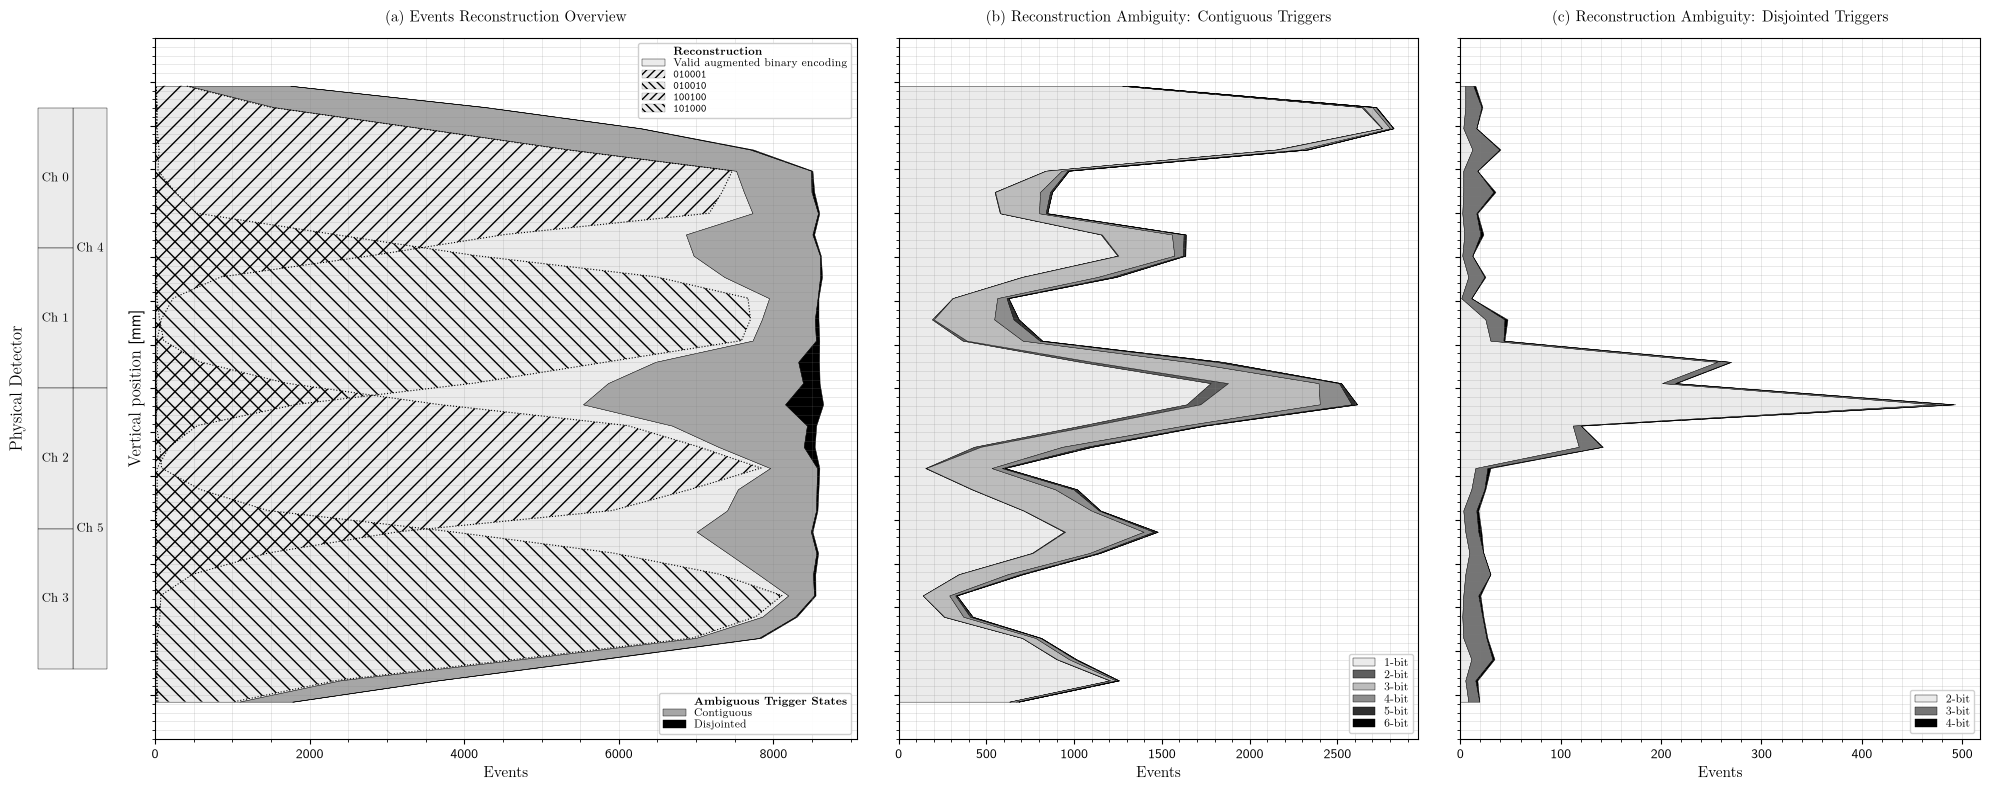

In [143]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D

try:
    from scipy.ndimage import label as label_components
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

# LaTeX and serif font setup
rc('text', usetex=True)
rc('font', family='serif')

# ==============================================================================
# Domain & Data Setup — absolute rates from trigger_per_bin_type (no renormalization)
# Drop index 0 ("no trigger") only: trigger_per_bin_type[1:, :]
# ==============================================================================
N_EVENTS = 10000  # events per run; trigger_per_bin_type is already / N_EVENTS
n_pos = trigger_per_bin_type.shape[1]
x = np.linspace(0, 80, n_pos)
x_centered = x - 35.75

mask = np.abs(x_centered) < 36
y_pos = x_centered[mask]

# Absolute per-state rates (exclude no-trigger). Shape: (63, n_pos)
abs_trigger_per_bin_type = trigger_per_bin_type[1:, :]

# ==============================================================================
# Helper Functions: Connectivity & 4x2 Grid Representation
# ==============================================================================
STRUCTURE_4 = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])

def is_contiguous_state(v6):
    """Returns True if state has exactly 1 orthogonally contiguous active region."""
    if v6 == 0:
        return False

    grid = np.ones((4, 2), dtype=int)
    if v6 & 0b010000: grid[0, 0] = grid[1, 0] = 0
    if v6 & 0b100000: grid[2, 0] = grid[3, 0] = 0
    if v6 & 0b000001: grid[0, 1] = 0
    if v6 & 0b000010: grid[1, 1] = 0
    if v6 & 0b000100: grid[2, 1] = 0
    if v6 & 0b001000: grid[3, 1] = 0

    black_pixels = (grid == 0).astype(int)

    if HAS_SCIPY:
        _, num_c = label_components(black_pixels, structure=STRUCTURE_4)
        return num_c == 1
    else:
        visited = np.zeros_like(black_pixels, dtype=bool)
        components = 0
        for r in range(4):
            for c in range(2):
                if black_pixels[r, c] and not visited[r, c]:
                    components += 1
                    q = [(r, c)]
                    visited[r, c] = True
                    while q:
                        cr, cc = q.pop(0)
                        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                            nr, nc = cr + dr, cc + dc
                            if 0 <= nr < 4 and 0 <= nc < 2:
                                if black_pixels[nr, nc] and not visited[nr, nc]:
                                    visited[nr, nc] = True
                                    q.append((nr, nc))
        return components == 1

# ==============================================================================
# Categorization & Bit-Count Grouping (0-based indexing into abs_trigger_per_bin_type)
# ==============================================================================
valid_set = set(valid_indices)  # 1-based bitmasks, as in earlier graphs
valid_set_0based = {i - 1 if min(valid_indices) > 0 else i for i in valid_indices}
all_states_0based = set(range(0, 63))
ambiguity_states = all_states_0based - valid_set_0based

contiguous_by_bits = {b: [] for b in range(1, 7)}
disjointed_by_bits = {b: [] for b in range(1, 7)}

for idx_0based in sorted(list(ambiguity_states)):
    v6 = idx_0based + 1  # 1 to 63 value for bit check
    bit_count = bin(v6).count('1')
    if is_contiguous_state(v6):
        contiguous_by_bits[bit_count].append(idx_0based)
    else:
        disjointed_by_bits[bit_count].append(idx_0based)

valid_idx = list(valid_set_0based)
all_contiguous_idx = [idx for bit_list in contiguous_by_bits.values() for idx in bit_list]
all_disjointed_idx = [idx for bit_list in disjointed_by_bits.values() for idx in bit_list]

def get_abs_counts(indices):
    """Absolute event counts vs position (excl. no-trigger by construction)."""
    if not indices:
        return np.zeros_like(y_pos)
    return abs_trigger_per_bin_type[indices, :].sum(axis=0)[mask] * N_EVENTS

# ==============================================================================
# Create 1x3 Side-by-Side Subplot Layout
# ==============================================================================
fig, (ax0, ax1, ax2, ax3) = plt.subplots(
    1, 4, figsize=(20, 8), sharey=True,
    gridspec_kw={'width_ratios': [0.15, 1.35, 1.0, 1.0]},
)

EDGE_LW = 0.3  # thin contour style (match middle-column fills / legends)
SUBTLE_GREY = '0.92'  # near-white fill (avoids harsh pure white)

def greyscale_by_yield(bit_groups):
    """Equidistant B/W by event-count rank (not magnitude-scaled).

    Sorted by increasing total events: fewest -> black, most -> subtle grey.
    """
    totals = {}
    for b_count, indices in bit_groups.items():
        if not indices:
            continue
        totals[b_count] = float(np.sum(get_abs_counts(indices)))
    if not totals:
        return {}
    ranked = sorted(totals.items(), key=lambda kv: kv[1])  # ascending events
    n = len(ranked)
    colors = {}
    for i, (b_count, _) in enumerate(ranked):
        if n == 1:
            gray = 0.5
        else:
            # increasing events: black (0) -> subtle grey (near-white), equal steps
            gray = float(SUBTLE_GREY) * (i / (n - 1))
        colors[b_count] = str(gray)
    return colors

# ==============================================================================
# ==============================================================================
# COLUMN 0: Sensor schematic (no axes; same vertical scale as other columns)
# ==============================================================================
# Rectangles defined corner-to-corner; text centered in each.
_schematic_rects = [
    ((12.5 + 0, +32), (12.5 + 12.5, 0), 'Ch 4'),
    ((12.5 + 0, -32), (12.5 + 12.5, 0), 'Ch 5'),
    ((0, +32), (12.5, +16), 'Ch 0'),
    ((0, +16), (12.5, 0), 'Ch 1'),
    ((0, -16), (12.5, 0), 'Ch 2'),
    ((0, -32), (12.5, -16), 'Ch 3'),  # bottom-left of 0..3 stack
]

for (x0, y0), (x1, y1), label in _schematic_rects:
    x, y = min(x0, x1), min(y0, y1)
    w, h = abs(x1 - x0), abs(y1 - y0)
    ax0.add_patch(Rectangle(
        (x, y), w, h,
        facecolor=SUBTLE_GREY, edgecolor='black', linewidth=EDGE_LW,
    ))
    ax0.text(
        (x0 + x1) / 2, (y0 + y1) / 2, label,
        ha='center', va='center', fontsize=9, color='black',
    )

ax0.set_xlim(-1.0, 27.0)
ax0.set_ylabel(r'Physical Detector', fontsize=12)
# Hide tick marks, tick numbers, and spines while keeping the ylabel
ax0.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False, color="white")
ax0.tick_params(axis='y', length=0, which='both')
for spine in ax0.spines.values():
    spine.set_visible(False)

# COLUMN 1: Overview — white / grey / black, event counts on bottom
# ==============================================================================
c_curr1 = np.zeros_like(y_pos)

valid_counts = get_abs_counts(valid_idx)
c_next1 = c_curr1 + valid_counts
ax1.fill_betweenx(
    y_pos, c_curr1, c_next1,
    facecolor=SUBTLE_GREY, edgecolor='black', linewidth=EDGE_LW, alpha=1.0,
    zorder=1,
)
c_curr1 = c_next1

contiguous_counts = get_abs_counts(all_contiguous_idx)
c_next1 = c_curr1 + contiguous_counts
ax1.fill_betweenx(
    y_pos, c_curr1, c_next1,
    facecolor='0.65', edgecolor='black', linewidth=EDGE_LW, alpha=1.0,
    zorder=1,
)
c_curr1 = c_next1

disjointed_counts = get_abs_counts(all_disjointed_idx)
c_next1 = c_curr1 + disjointed_counts
ax1.fill_betweenx(
    y_pos, c_curr1, c_next1,
    facecolor='black', edgecolor='black', linewidth=EDGE_LW, alpha=1.0,
    zorder=1,
)

# Non-cumulative valid-state profiles: hatched fills (// / \\) + overlay lines
valid_linestyles = [':', '--', '-.', (0, (3, 1, 1, 1))]
valid_hatches = ['//', '\\\\']  # double-density alternating
valid_sorted = sorted(list(valid_set))

for i, idx in enumerate(valid_sorted):
    bit_str = f'{idx:06b}'
    counts = abs_trigger_per_bin_type[idx - 1][mask] * N_EVENTS  # non-cumulative
    hatch = valid_hatches[i % len(valid_hatches)]
    ax1.fill_betweenx(
        y_pos, 0, counts,
        facecolor='none', hatch=hatch, edgecolor='black',
        linewidth=0.0, alpha=1.0, zorder=2,
    )
    ax1.plot(
        counts,
        y_pos,
        color='black',
        linestyle=":",
        linewidth=0.8,
        zorder=3,
    )

xmax1 = float(np.max(c_next1)) * 1.05 if np.max(c_next1) > 0 else N_EVENTS
ax1.set_xlim(0, xmax1)
ax1.set_ylabel(r'Vertical position $[\mathrm{mm}]$', fontsize=12)
ax1.set_xlabel(r'Events', fontsize=11)
ax1.set_title(r'(a) Events Reconstruction Overview', fontsize=11, pad=12)
ax1.grid(which='both', lw=0.4, ls='-', color='gray', alpha=0.3)
ax1.minorticks_on()

# Sectioned legend: Reconstruction / Ambiguous State
legend_elements = [
    Patch(facecolor='none', edgecolor='none', label=r'\textbf{Reconstruction}'),
    Patch(
        facecolor=SUBTLE_GREY, edgecolor='black', linewidth=EDGE_LW,
        label=r'Valid augmented binary encoding',
    ),
    # Patch(facecolor='none', edgecolor='none', label=r'\textit{Valid States}'),
]
for i, idx in enumerate(valid_sorted):
    bit_str = f'{idx:06b}'
    hatch_type = "////" if i % 2 == 0 else "\\\\\\\\"
    legend_elements.append(
        Patch(
            linestyle=":",
            facecolor=SUBTLE_GREY, edgecolor='black', linewidth=EDGE_LW, hatch=hatch_type,
            label=rf'$\mathtt{{{bit_str}}}$',
        )
    )

legend1 = ax1.legend(
    handles=legend_elements,
    fontsize=7.5,
    framealpha=0.95,
    loc='upper right',
    handlelength=2.2,
)
ax1.add_artist(legend1)

ambiguous_legend_items  = [
    # Patch(facecolor='none', edgecolor='none', label=' '),
    Patch(facecolor='none', edgecolor='none', label=r'\textbf{Ambiguous Trigger States}'),
    Patch(facecolor='0.65', edgecolor='black', linewidth=EDGE_LW, label=r'Contiguous'),
    Patch(facecolor='black', edgecolor='black', linewidth=EDGE_LW, label=r'Disjointed'),
]
ax1.legend(
    handles=ambiguous_legend_items,
    fontsize=7.5,
    framealpha=0.95,
    loc='lower right',
    handlelength=2.2,
)



# ==============================================================================
# COLUMN 2: Contiguous Failures Breakdown — absolute event counts (B/W by yield)
# ==============================================================================
contig_colors = greyscale_by_yield(contiguous_by_bits)
c_curr2 = np.zeros_like(y_pos)

for b_count in range(1, 7):
    indices = contiguous_by_bits[b_count]
    if not indices:
        continue

    counts = get_abs_counts(indices)
    c_next2 = c_curr2 + counts

    ax2.fill_betweenx(
        y_pos, c_curr2, c_next2,
        facecolor=contig_colors[b_count], edgecolor='black', linewidth=EDGE_LW, alpha=1.0,
        label=rf'{b_count}-bit'
    )
    c_curr2 = c_next2

xmax2 = float(np.max(c_curr2)) * 1.05 if np.max(c_curr2) > 0 else 100
ax2.set_xlim(0, xmax2)
ax2.set_xlabel(r'Events', fontsize=11)
ax2.set_title(r'(b) Reconstruction Ambiguity: Contiguous Triggers', fontsize=11, pad=12)
ax2.grid(which='both', lw=0.4, ls='-', color='gray', alpha=0.3)
ax2.minorticks_on()
ax2.legend(fontsize=8, framealpha=0.9, loc='lower right')

# ==============================================================================
# COLUMN 3: Disjointed Failures Breakdown — absolute event counts (B/W by yield)
# ==============================================================================
disjoint_colors = greyscale_by_yield(disjointed_by_bits)
c_curr3 = np.zeros_like(y_pos)

for b_count in range(1, 7):
    indices = disjointed_by_bits[b_count]
    if not indices:
        continue

    counts = get_abs_counts(indices)
    c_next3 = c_curr3 + counts

    ax3.fill_betweenx(
        y_pos, c_curr3, c_next3,
        facecolor=disjoint_colors[b_count], edgecolor='black', linewidth=EDGE_LW, alpha=1.0,
        label=rf'{b_count}-bit'
    )
    c_curr3 = c_next3

xmax3 = float(np.max(c_curr3)) * 1.05 if np.max(c_curr3) > 0 else 100
ax3.set_xlim(0, xmax3)
ax3.set_ylim(-40, 40)
ax3.set_yticks(np.arange(-35, 40, 5))
ax3.set_xlabel(r'Events', fontsize=11)
ax3.set_title(r'(c) Reconstruction Ambiguity: Disjointed Triggers', fontsize=11, pad=12)
ax3.grid(which='both', lw=0.4, ls='-', color='gray', alpha=0.3)
ax3.minorticks_on()
ax3.legend(fontsize=8, framealpha=0.9, loc='lower right')

fig.tight_layout()
plt.savefig("valid_reconstruction_distribution.svg", dpi=300)
plt.show()
